In [1]:
# ==========================
# 0) 数据预处理（可选）
# 
# 如果发现内核图像异常，可以直接运行以下单元格，强制利用内核稳定修补重新生成一次 nc 文件
# 生成的文件默认名为 `typhoon_azimuthal_avg_budget.nc`，可以直接被下一个单元格读取。
# 如果你想使用随体坐标（减去台风移动速度）来进行分析，可以带上 --subtract-translation-speed
# ==========================
!python cm1_azimuthal_avg_budget_full_grouped_residual.py --subtract-translation-speed


Traceback (most recent call last):
  File "c:\Users\14351\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\backends\file_manager.py", line 211, in _acquire_with_cache_info
    file = self._cache[self._key]
           ~~~~~~~~~~~^^^^^^^^^^^
  File "c:\Users\14351\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\backends\lru_cache.py", line 56, in __getitem__
    value = self._cache[key]
            ~~~~~~~~~~~^^^^^
KeyError: [<class 'netCDF4._netCDF4.Dataset'>, ('e:\\科研\\数值模式cm1\\dataset\\cm1out.nc',), 'r', (('clobber', True), ('diskless', False), ('format', 'NETCDF4'), ('persist', False)), '37b7e367-6781-4418-8407-1e547a1a5397']

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "e:\科研\数值模式cm1\cm1_azimuthal_avg_budget_full_grouped_residual.py", line 917, in <module>
    main()
  File "e:\科研\数值模式cm1\cm1_azimuthal_avg_budget_full_grouped_residual.py", line 913, in main
    run(config)
  File "e:\

# 径向速度诊断单页绘图

本 Notebook 读取昨天生成的结果文件，支持两种模式：
- `time_point`：绘制某一时次的径向风场 + 径向收支项 + 收支项和
- `time_range`：绘制某一时间段平均的所有诊断项，并额外显示起始/结束时刻的径向风场

时间参数均使用 **小时** 输入，程序内部自动换算为秒。

<>:56: SyntaxWarning: invalid escape sequence '\w'
<>:56: SyntaxWarning: invalid escape sequence '\w'
C:\Users\14351\AppData\Local\Temp\ipykernel_19788\3487357474.py:56: SyntaxWarning: invalid escape sequence '\w'
  "dataset\wind_Thompson.nc",


读取文件: dataset\wind_Thompson.nc
ur 色阶范围: [-17.242, 17.242]
普通诊断项色阶范围: [-0.001966, 0.001966] (p97.0)
大项(sum/pgrad/curv/tendency)色阶范围: [-0.042763, 0.042763] (p98.5)
当前开关 plot_non_raw_only = True
diag_color_mode = symlog
symlog linthresh (small/large): 1.573e-04, 3.421e-03
已按参数应用平滑：['pgrad_mean', 'pgrad_eddy', 'U_magf', 'U_eagf']，smooth_sigma = 2.0


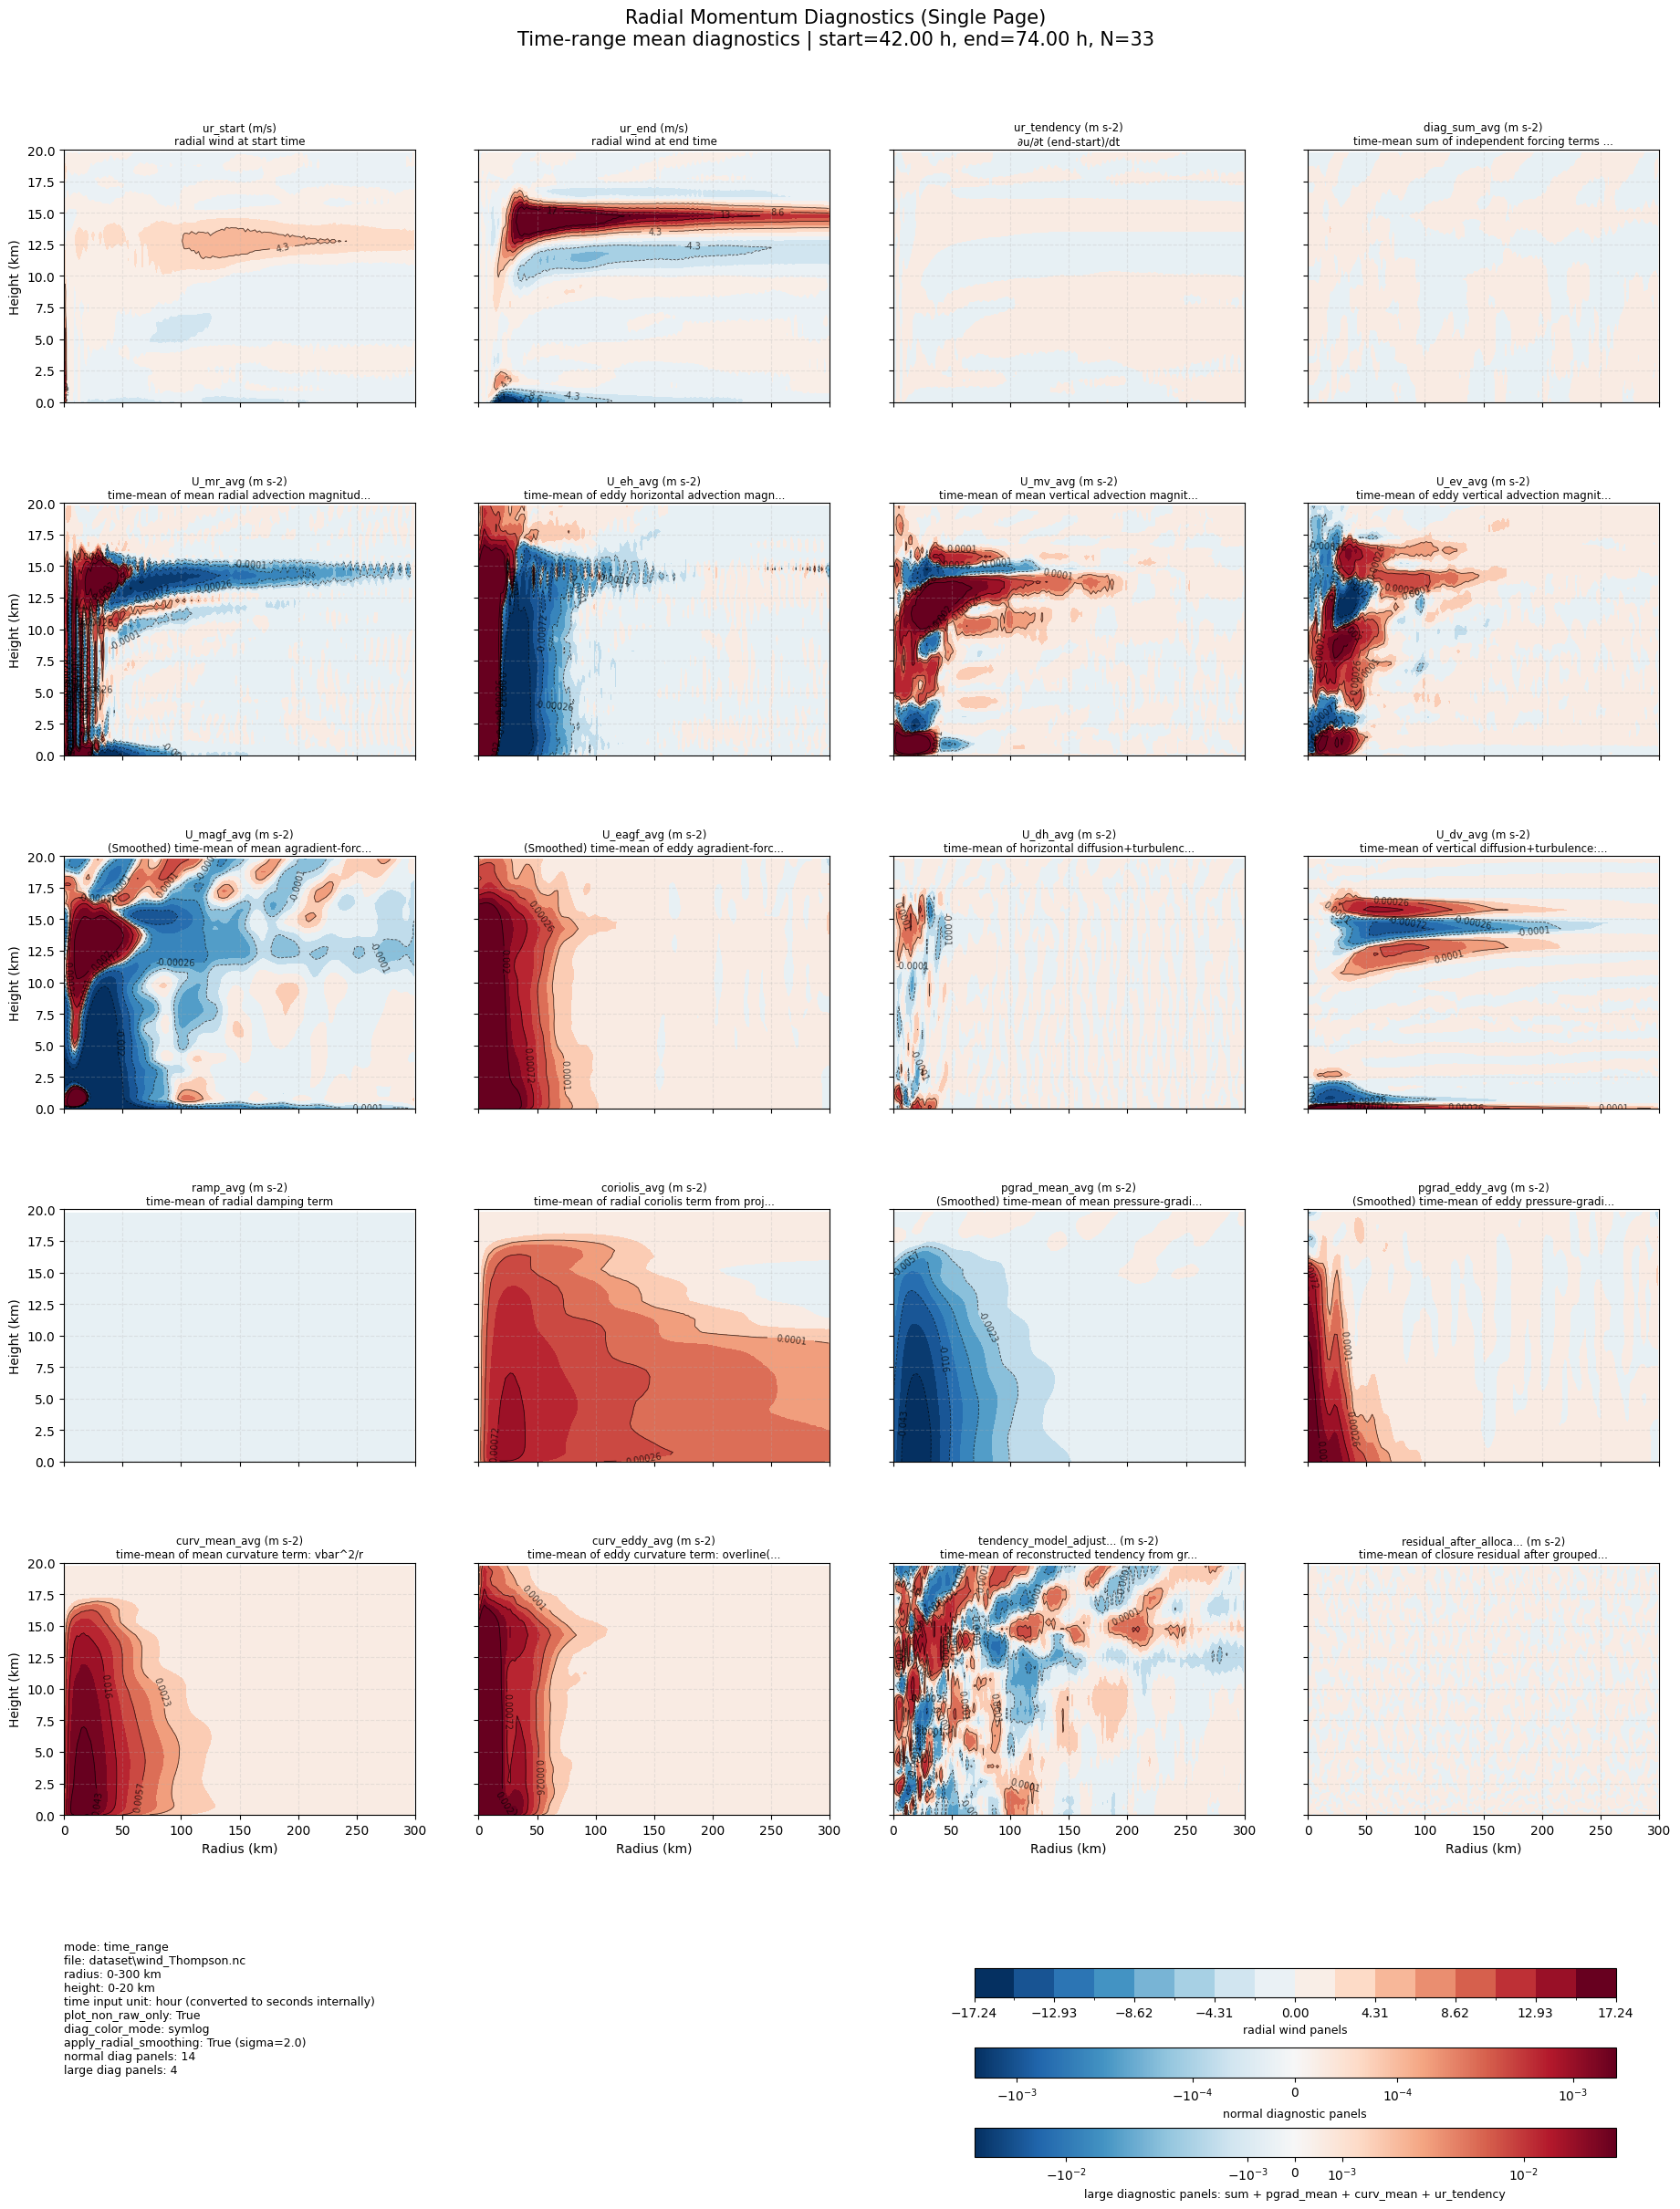

诊断绘图完成。


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.colors import BoundaryNorm, SymLogNorm
from matplotlib.cm import ScalarMappable
from scipy.ndimage import gaussian_filter1d

# ==========================
# 1) 用户参数区
# ==========================
plot_mode = "time_range"  # 可选: "time_point" 或 "time_range"

# 开关：True=只画处理后的非 raw 项；False=raw 和非 raw 都画
plot_non_raw_only = True

# 针对包含 pgrad 及派生项的锯齿问题，应用径向平滑
apply_radial_smoothing = True
# 平滑高斯核的标准差 (单位：网格点，由于 dr=2km，sigma=2 约平滑 4km 尺度)
smooth_sigma = 2.0
# 需要被平滑的诊断项前缀（会自动匹配 avg 后缀）
smooth_targets = ["pgrad_mean", "pgrad_eddy", "U_magf", "U_eagf"]

# 单时次模式参数（单位: 小时）
target_hour = 60.0

# 时间段模式参数（单位: 小时）
start_hour = 42.0
end_hour = 74.0

# 绘图范围
max_r_km = 300.0
max_z_km = 20.0

# 色阶
n_levels_ur = 17
n_levels_diag = 17

# 诊断项色标模式："linear" 或 "symlog"
# symlog 更适合“眼墙极值很大、流出层信号较弱”的场景
diag_color_mode = "symlog"

# 百分位裁剪：降低可增强流出层细节，但会让眼墙极值饱和
small_clip_percentile = 97.0
large_clip_percentile = 98.5

# symlog 线性区阈值（相对各组 vmax 的比例）
small_linthresh_ratio = 0.08
large_linthresh_ratio = 0.08

# 单页子图列数（会自动计算行数）
ncols = 4

# 结果文件候选路径（按优先级从上到下尝试）
candidate_files = [
    "dataset\wind_Thompson.nc",
    
    "C:/cm1_work/dataset/wind_Thompson.nc",
]

# 处理后诊断项候选（含 raw 和 non-raw）
preferred_diag_all = [
    "U_mr", "U_eh", "U_mv", "U_ev",
    "U_magf", "U_eagf", "U_dh", "U_dv", "ramp",
    "U_mr_raw", "U_eh_raw", "U_mv_raw", "U_ev_raw",
    "U_magf_raw", "U_eagf_raw", "U_dh_raw", "U_dv_raw", "ramp_raw",
    "coriolis", "pgrad_mean", "pgrad_eddy", "curv_mean", "curv_eddy",
    "br_total_raw", "tendency_model_raw", "tendency_model_adjusted",
    "residual_raw", "residual_after_allocation",
]

if plot_non_raw_only:
    preferred_diag = [v for v in preferred_diag_all if not v.endswith("_raw")]
else:
    preferred_diag = list(preferred_diag_all)

# ==========================
# 2) 辅助函数
# ==========================
def choose_existing_file(candidates):
    existing_but_unreadable = []
    for p in candidates:
        if not os.path.exists(p):
            continue
        try:
            with Dataset(p, "r"):
                return p
        except OSError as e:
            print(f"跳过不可读 NetCDF 文件: {p} ({e})")
            existing_but_unreadable.append(p)

    if existing_but_unreadable:
        raise OSError("候选文件存在，但都不是可读的 NetCDF 文件。")

    raise FileNotFoundError("未找到结果文件，请检查路径。")


def nearest_time_index(time_s, target_s):
    return int(np.argmin(np.abs(time_s - target_s)))


def symmetric_levels_from_data(arrays, n_levels, floor, clip_percentile=99.0):
    if len(arrays) == 0:
        vmax = floor
    else:
        stack = np.stack(arrays, axis=0)
        vmax = np.nanpercentile(np.abs(stack), clip_percentile)
        vmax = max(float(vmax), floor)
    levels = np.linspace(-vmax, vmax, n_levels)
    return levels, vmax


def make_symlog_levels(vmax, linthresh, n_levels):
    n_half = max((n_levels - 1) // 2, 4)
    n_linear = max(3, n_half // 3)
    n_log = max(2, n_half - n_linear)

    pos_linear = np.linspace(0.0, linthresh, n_linear, endpoint=False)
    pos_log = np.geomspace(max(linthresh, 1e-14), vmax, n_log + 1)
    pos = np.unique(np.concatenate([pos_linear, pos_log]))

    levels = np.concatenate([-pos[::-1], [0.0], pos])
    levels = np.unique(levels)
    if levels.size < 7:
        levels = np.linspace(-vmax, vmax, max(n_levels, 9))
    return levels


def get_var_2d(nc, vname, tidx, z_mask, r_mask):
    return np.asarray(nc.variables[vname][tidx, z_mask, r_mask], dtype=float)


def get_var_2d_mean(nc, vname, time_mask, z_mask, r_mask):
    data = np.asarray(nc.variables[vname][time_mask, :, :], dtype=float)
    return np.nanmean(data[:, z_mask, :][:, :, r_mask], axis=0)


def shorten_text(text, max_len):
    text = str(text)
    if len(text) <= max_len:
        return text
    return text[: max_len - 1] + "..."


def smooth_2d_field(field_2d, sigma):
    """
    对 (Z, R) 的二维场只沿 R 方向（axis=1）做高斯平滑
    以消除差分导致的高频径向波动。
    """
    return gaussian_filter1d(field_2d, sigma=sigma, axis=1)


def is_smooth_target(name, targets):
    for t in targets:
        if name == t or name == f"{t}_avg":
            return True
    return False


# ==========================
# 3) 读取数据并组织绘图变量
# ==========================
nc_file = choose_existing_file(candidate_files)
print(f"读取文件: {nc_file}")

with Dataset(nc_file, "r") as nc:
    time_s = np.asarray(nc.variables["time"][:], dtype=float)
    time_h = time_s / 3600.0

    r_arr = np.asarray(nc.variables["r"][:], dtype=float)
    if "z" in nc.variables:
        z_arr = np.asarray(nc.variables["z"][:], dtype=float)
    elif "zh" in nc.variables:
        z_arr = np.asarray(nc.variables["zh"][:], dtype=float)
    else:
        raise KeyError("未找到 z 或 zh 坐标变量。")

    r_mask = r_arr <= max_r_km
    z_mask = z_arr <= max_z_km
    r_plot = r_arr[r_mask]
    z_plot = z_arr[z_mask]

    var_names = list(nc.variables.keys())
    diag_vars = [v for v in preferred_diag if v in var_names]

    if len(diag_vars) == 0:
        raise KeyError("结果文件中未找到可绘制的处理后诊断项变量。")

    field_data = {}
    field_data_unsmoothed = {}
    field_units = {}
    field_long_name = {}

    if plot_mode == "time_point":
        target_s = target_hour * 3600.0
        t_idx = nearest_time_index(time_s, target_s)

        field_data["ur"] = get_var_2d(nc, "ur", t_idx, z_mask, r_mask)
        field_units["ur"] = getattr(nc.variables["ur"], "units", "")
        field_long_name["ur"] = getattr(nc.variables["ur"], "long_name", "ur")

        for v in diag_vars:
            data_raw = get_var_2d(nc, v, t_idx, z_mask, r_mask)
            field_data_unsmoothed[v] = data_raw
            if apply_radial_smoothing and is_smooth_target(v, smooth_targets):
                field_data[v] = smooth_2d_field(data_raw, smooth_sigma)
                lname_prefix = "(Smoothed) "
            else:
                field_data[v] = data_raw
                lname_prefix = ""

            field_units[v] = getattr(nc.variables[v], "units", "")
            field_long_name[v] = lname_prefix + getattr(nc.variables[v], "long_name", v)

        # 真正物理上互相独立的收支项 (平流项移至方程右侧需乘 -1)
        # 注意：sum 统一使用未平滑原始项，避免 pgrad 相关项被平滑后改变收支闭合含义。
        sum_weights = {
            "U_mr": -1, "U_eh": -1, "U_mv": -1, "U_ev": -1,
            "U_magf": 1, "U_eagf": 1, "U_dh": 1, "U_dv": 1, "ramp": 1
        }
        if not plot_non_raw_only:
            sum_weights = {k + "_raw": v for k, v in sum_weights.items()}

        valid_keys = [k for k in sum_weights if k in field_data_unsmoothed]
        if valid_keys:
            field_data["diag_sum"] = np.sum(
                np.stack([field_data_unsmoothed[k] * sum_weights[k] for k in valid_keys], axis=0),
                axis=0,
            )
            field_units["diag_sum"] = field_units.get(valid_keys[0], "")
        else:
            field_data["diag_sum"] = np.zeros_like(field_data["ur"])
            field_units["diag_sum"] = ""

        field_long_name["diag_sum"] = "sum of independent forcing terms (unsmoothed)"

        panel_order = ["ur", "diag_sum"] + diag_vars

        title_mode = (
            f"Time-point diagnostics | target={target_hour:.2f} h, "
            f"actual={time_h[t_idx]:.2f} h (idx={t_idx})"
        )

    elif plot_mode == "time_range":
        if end_hour < start_hour:
            raise ValueError("end_hour 必须 >= start_hour")

        start_s = start_hour * 3600.0
        end_s = end_hour * 3600.0

        t0 = nearest_time_index(time_s, start_s)
        t1 = nearest_time_index(time_s, end_s)
        if t1 < t0:
            t0, t1 = t1, t0

        time_mask = np.zeros_like(time_s, dtype=bool)
        time_mask[t0:t1 + 1] = True

        field_data["ur_start"] = get_var_2d(nc, "ur", t0, z_mask, r_mask)
        field_data["ur_end"] = get_var_2d(nc, "ur", t1, z_mask, r_mask)
        field_units["ur_start"] = getattr(nc.variables["ur"], "units", "")
        field_units["ur_end"] = getattr(nc.variables["ur"], "units", "")
        field_long_name["ur_start"] = "radial wind at start time"
        field_long_name["ur_end"] = "radial wind at end time"

        # === 新增计算风速的变化率 ur_tendency = (ur_end - ur_start)/dt ===
        delta_t_s = end_s - start_s
        if delta_t_s > 0:
            field_data["ur_tendency"] = (field_data["ur_end"] - field_data["ur_start"]) / delta_t_s
        else:
            field_data["ur_tendency"] = np.zeros_like(field_data["ur_start"])
        field_units["ur_tendency"] = "m s-2"
        field_long_name["ur_tendency"] = "∂u/∂t (end-start)/dt"

        diag_avg_names = []
        for v in diag_vars:
            v_avg_name = f"{v}_avg"
            diag_avg_names.append(v_avg_name)
            data_raw = get_var_2d_mean(nc, v, time_mask, z_mask, r_mask)
            field_data_unsmoothed[v_avg_name] = data_raw

            if apply_radial_smoothing and is_smooth_target(v_avg_name, smooth_targets):
                field_data[v_avg_name] = smooth_2d_field(data_raw, smooth_sigma)
                lname_prefix = "(Smoothed) "
            else:
                field_data[v_avg_name] = data_raw
                lname_prefix = ""

            field_units[v_avg_name] = getattr(nc.variables[v], "units", "")
            field_long_name[v_avg_name] = lname_prefix + f"time-mean of {getattr(nc.variables[v], 'long_name', v)}"

        # 真正物理上互相独立的收支项 (平流项移至方程右侧需乘 -1)
        # 注意：sum 统一使用未平滑原始项，避免 pgrad 相关项被平滑后改变收支闭合含义。
        sum_weights = {
            "U_mr": -1, "U_eh": -1, "U_mv": -1, "U_ev": -1,
            "U_magf": 1, "U_eagf": 1, "U_dh": 1, "U_dv": 1, "ramp": 1
        }
        if not plot_non_raw_only:
            sum_weights = {k + "_raw": v for k, v in sum_weights.items()}

        valid_keys_avg = [f"{k}_avg" for k in sum_weights if f"{k}_avg" in field_data_unsmoothed]

        if valid_keys_avg:
            field_data["diag_sum_avg"] = np.sum(
                np.stack(
                    [field_data_unsmoothed[k] * sum_weights[k.replace("_avg", "")] for k in valid_keys_avg],
                    axis=0,
                ),
                axis=0,
            )
            field_units["diag_sum_avg"] = field_units.get(valid_keys_avg[0], "")
        else:
            field_data["diag_sum_avg"] = np.zeros_like(field_data["ur_start"])
            field_units["diag_sum_avg"] = ""

        field_long_name["diag_sum_avg"] = "time-mean sum of independent forcing terms (unsmoothed)"

        # 将 ur_tendency 插入到绘图顺序中
        panel_order = ["ur_start", "ur_end", "ur_tendency", "diag_sum_avg"] + diag_avg_names

        title_mode = (
            f"Time-range mean diagnostics | start={time_h[t0]:.2f} h, end={time_h[t1]:.2f} h, "
            f"N={np.sum(time_mask)}"
        )

    else:
        raise ValueError("plot_mode 只能是 'time_point' 或 'time_range'")

# ==========================
# 4) 统一色阶（分组）
# ==========================
# 排除 ur_tendency，它不用径向风速的 colorbar
ur_keys = [k for k in panel_order if k.startswith("ur") and k != "ur_tendency"]

# 这三类幅值通常显著偏大，单独共用一个 colorbar。在此加入 ur_tendency 并同享大 colorbar
large_key_set = {
    "diag_sum", "diag_sum_avg",
    "pgrad_mean", "pgrad_mean_avg",
    "curv_mean", "curv_mean_avg",
    "ur_tendency"
}
large_diag_keys = [k for k in panel_order if k in large_key_set]
small_diag_keys = [k for k in panel_order if (k not in ur_keys and k not in large_diag_keys)]

ur_levels, ur_abs = symmetric_levels_from_data(
    arrays=[field_data[k] for k in ur_keys],
    n_levels=n_levels_ur,
    floor=1e-8,
    clip_percentile=99.0,
)

small_levels, small_abs = symmetric_levels_from_data(
    arrays=[field_data[k] for k in small_diag_keys],
    n_levels=n_levels_diag,
    floor=1e-12,
    clip_percentile=small_clip_percentile,
)

large_levels, large_abs = symmetric_levels_from_data(
    arrays=[field_data[k] for k in large_diag_keys],
    n_levels=n_levels_diag,
    floor=1e-12,
    clip_percentile=large_clip_percentile,
)

ur_norm = BoundaryNorm(ur_levels, ncolors=256, clip=True)

if diag_color_mode == "symlog":
    small_linthresh = max(small_abs * small_linthresh_ratio, 1e-12)
    large_linthresh = max(large_abs * large_linthresh_ratio, 1e-12)

    small_levels = make_symlog_levels(small_abs, small_linthresh, n_levels_diag)
    large_levels = make_symlog_levels(large_abs, large_linthresh, n_levels_diag)

    small_norm = SymLogNorm(linthresh=small_linthresh, vmin=-small_abs, vmax=small_abs, base=10)
    large_norm = SymLogNorm(linthresh=large_linthresh, vmin=-large_abs, vmax=large_abs, base=10)
else:
    small_norm = BoundaryNorm(small_levels, ncolors=256, clip=True)
    large_norm = BoundaryNorm(large_levels, ncolors=256, clip=True)

print(f"ur 色阶范围: [{-ur_abs:.3f}, {ur_abs:.3f}]")
print(f"普通诊断项色阶范围: [{-small_abs:.6f}, {small_abs:.6f}] (p{small_clip_percentile})")
print(f"大项(sum/pgrad/curv/tendency)色阶范围: [{-large_abs:.6f}, {large_abs:.6f}] (p{large_clip_percentile})")
print(f"当前开关 plot_non_raw_only = {plot_non_raw_only}")
print(f"diag_color_mode = {diag_color_mode}")
if diag_color_mode == "symlog":
    print(f"symlog linthresh (small/large): {small_linthresh:.3e}, {large_linthresh:.3e}")
if apply_radial_smoothing:
    print(f"已按参数应用平滑：{smooth_targets}，smooth_sigma = {smooth_sigma}")

# ==========================
# 5) 单页绘图
# ==========================
R, Z = np.meshgrid(r_plot, z_plot)
n_panels = len(panel_order)
nrows = int(np.ceil(n_panels / ncols))
fig_h = 4.2 * nrows + 4.0

fig, axes = plt.subplots(nrows, ncols, figsize=(19, fig_h), sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).ravel()

for i, key in enumerate(panel_order):
    ax = axes_flat[i]
    data = field_data[key]

    if key in ur_keys:
        levels = ur_levels
        norm = ur_norm
    elif key in large_diag_keys:
        levels = large_levels
        norm = large_norm
    else:
        levels = small_levels
        norm = small_norm

    ax.contourf(R, Z, data, levels=levels, cmap="RdBu_r", norm=norm, extend="both")

    contour_levels = levels[::2]
    contour_levels = contour_levels[~np.isclose(contour_levels, 0.0, atol=1e-15)]
    if contour_levels.size > 0:
        cs = ax.contour(R, Z, data, levels=contour_levels, colors="k", linewidths=0.6, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.2g")

    unit = field_units.get(key, "")
    lname = field_long_name.get(key, key)
    short_key = shorten_text(key, 22)
    short_lname = shorten_text(lname, 44)

    if unit:
        title1 = f"{short_key} ({unit})"
    else:
        title1 = short_key
    ax.set_title(f"{title1}\n{short_lname}", fontsize=8.5, pad=4)

    ax.grid(True, linestyle="--", alpha=0.25)
    ax.set_xlim(0, max_r_km)
    ax.set_ylim(0, max_z_km)

for i, ax in enumerate(axes_flat):
    if i >= n_panels:
        ax.axis("off")
        continue
    if i % ncols == 0:
        ax.set_ylabel("Height (km)", fontsize=10)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("Radius (km)", fontsize=10)

fig.suptitle(
    "Radial Momentum Diagnostics (Single Page)\n" + title_mode,
    fontsize=15,
    y=0.992,
)
fig.subplots_adjust(left=0.055, right=0.975, bottom=0.20, top=0.93, wspace=0.18, hspace=0.40)

info_lines = [
    f"mode: {plot_mode}",
    f"file: {nc_file}",
    f"radius: 0-{max_r_km:.0f} km",
    f"height: 0-{max_z_km:.0f} km",
    "time input unit: hour (converted to seconds internally)",
    f"plot_non_raw_only: {plot_non_raw_only}",
    f"diag_color_mode: {diag_color_mode}",
    f"apply_radial_smoothing: {apply_radial_smoothing} (sigma={smooth_sigma})",
    f"normal diag panels: {len(small_diag_keys)}",
    f"large diag panels: {len(large_diag_keys)}",
]
fig.text(0.055, 0.145, "\n".join(info_lines), ha="left", va="top", fontsize=9)

sm_ur = ScalarMappable(norm=ur_norm, cmap="RdBu_r")
sm_ur.set_array([])
sm_small = ScalarMappable(norm=small_norm, cmap="RdBu_r")
sm_small.set_array([])
sm_large = ScalarMappable(norm=large_norm, cmap="RdBu_r")
sm_large.set_array([])

cax1 = fig.add_axes([0.58, 0.12, 0.37, 0.013])
cax2 = fig.add_axes([0.58, 0.085, 0.37, 0.013])
cax3 = fig.add_axes([0.58, 0.05, 0.37, 0.013])

cb1 = fig.colorbar(sm_ur, cax=cax1, orientation="horizontal", ticks=ur_levels[::2])
cb1.set_label("radial wind panels", fontsize=9)

cb2 = fig.colorbar(sm_small, cax=cax2, orientation="horizontal")
cb2.set_label("normal diagnostic panels", fontsize=9)

cb3 = fig.colorbar(sm_large, cax=cax3, orientation="horizontal")
cb3.set_label("large diagnostic panels: sum + pgrad_mean + curv_mean + ur_tendency", fontsize=9)

plt.show()
print("诊断绘图完成。")

In [3]:
# ==========================
# 1.1) sum 面板显示平滑（无损）
# 仅影响绘图显示，不改变 sum 的原始构造与闭合核对来源
# ==========================
smooth_sum_panel = True  # True: 对 sum 面板做径向平滑
smooth_v_sum_panel = smooth_sum_panel  # 兼容已有切向接口

读取文件(自定义组合): dataset\wind_Thompson.nc
[COMBO] expression = U_magf - U_mr
[COMBO] norm_mode = none, scale = 1.000e+00 (original)
[COMBO] smoothing = True, sigma = 2.0
[COMBO] clip_percentile = 98.5


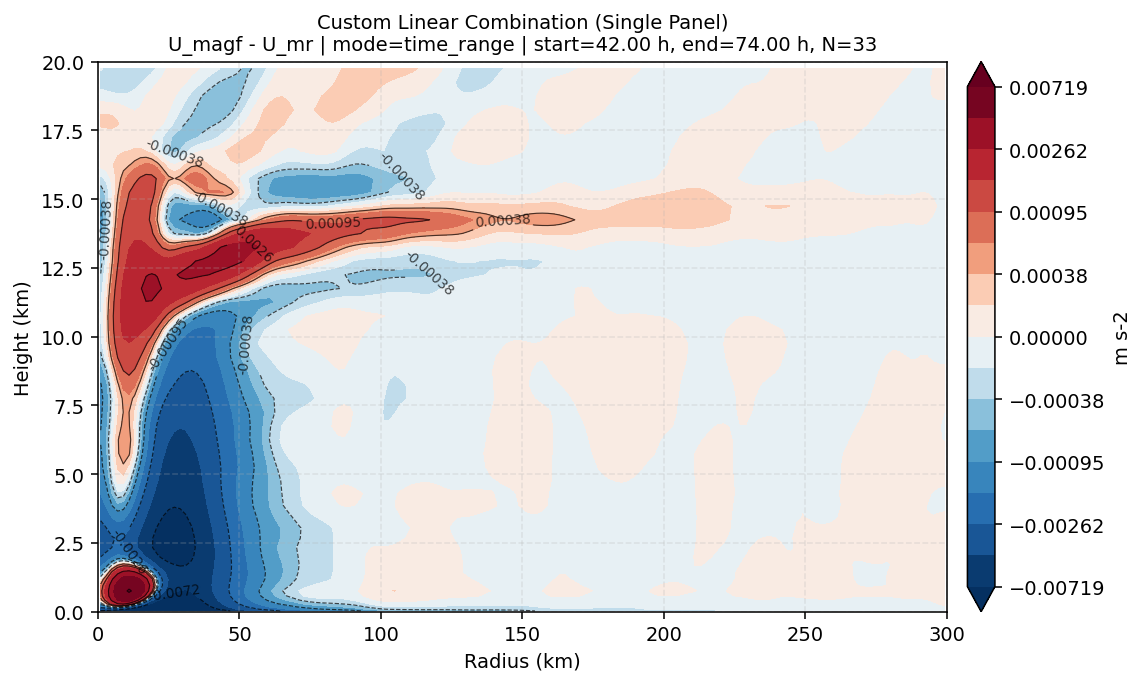

In [4]:
# ==========================
# 5.1) 自定义线性组合绘图窗口（默认: U_magf - U_mv）
# 通过修改 combo_terms 可绘制任意项（符号/系数/项数不限）的和
# ==========================

if "choose_existing_file" not in globals():
    raise RuntimeError("请先运行第3个单元，再运行本单元。")

# ---- 用户参数区（可直接改） ----
combo_plot_mode = plot_mode  # "time_point" 或 "time_range"
combo_target_hour = target_hour
combo_start_hour = start_hour
combo_end_hour = end_hour

# 线性组合：[(系数, 变量名), ...]
# 示例默认：U_magf - U_mv
combo_terms = [
    (1.0, "U_magf"),
    (-1.0, "U_mr")
]

# 是否使用 raw 变量（若变量不存在 *_raw 会报错）
combo_use_raw = False

# 无损显示平滑：仅对最终组合场做平滑，不改变原始变量
combo_apply_smoothing = apply_radial_smoothing
combo_smooth_sigma = smooth_sigma

# 结果标准化模式："none" | "maxabs" | "std"
combo_norm_mode = "none"
combo_norm_eps = 1e-12

# 组合场色阶百分位
combo_clip_percentile = large_clip_percentile


def _resolve_combo_var_name(base_name, use_raw=False):
    if use_raw and not base_name.endswith("_raw"):
        return f"{base_name}_raw"
    return base_name


def _normalize_combo_field(field, mode, eps=1e-12):
    if mode == "none":
        return field, 1.0, "original"
    if mode == "maxabs":
        scale = float(np.nanmax(np.abs(field)))
        scale = max(scale, eps)
        return field / scale, scale, "maxabs"
    if mode == "std":
        scale = float(np.nanstd(field))
        scale = max(scale, eps)
        return field / scale, scale, "std"
    raise ValueError("combo_norm_mode 只能是 'none' / 'maxabs' / 'std'")


def _format_combo_expression(term_list, use_raw=False):
    chunks = []
    for i, (coef, base_name) in enumerate(term_list):
        var_name = _resolve_combo_var_name(base_name, use_raw=use_raw)
        sign = "+" if coef >= 0 else "-"
        c = abs(float(coef))
        if np.isclose(c, 1.0):
            core = f"{var_name}"
        else:
            core = f"{c:g}*{var_name}"
        if i == 0:
            chunks.append(core if sign == "+" else f"-{core}")
        else:
            chunks.append(f" {sign} {core}")
    return "".join(chunks)


if len(combo_terms) == 0:
    raise ValueError("combo_terms 不能为空。")

nc_combo = choose_existing_file(candidate_files)
print(f"读取文件(自定义组合): {nc_combo}")

with Dataset(nc_combo, "r") as nc:
    time_s = np.asarray(nc.variables["time"][:], dtype=float)
    time_h = time_s / 3600.0

    r_arr = np.asarray(nc.variables["r"][:], dtype=float)
    if "z" in nc.variables:
        z_arr = np.asarray(nc.variables["z"][:], dtype=float)
    elif "zh" in nc.variables:
        z_arr = np.asarray(nc.variables["zh"][:], dtype=float)
    else:
        raise KeyError("未找到 z 或 zh 坐标变量。")

    r_mask = r_arr <= max_r_km
    z_mask = z_arr <= max_z_km
    r_plot = r_arr[r_mask]
    z_plot = z_arr[z_mask]

    # 检查变量存在性
    resolved_vars = [_resolve_combo_var_name(v, use_raw=combo_use_raw) for _, v in combo_terms]
    miss = [v for v in resolved_vars if v not in nc.variables]
    if miss:
        raise KeyError(f"自定义组合失败，缺少变量: {miss}")

    if combo_plot_mode == "time_point":
        target_s = combo_target_hour * 3600.0
        t_idx = nearest_time_index(time_s, target_s)

        combo_field = None
        for coef, base_name in combo_terms:
            vn = _resolve_combo_var_name(base_name, use_raw=combo_use_raw)
            arr = get_var_2d(nc, vn, t_idx, z_mask, r_mask)
            if combo_field is None:
                combo_field = np.zeros_like(arr, dtype=float)
            combo_field += float(coef) * arr

        title_time = f"target={combo_target_hour:.2f} h, actual={time_h[t_idx]:.2f} h (idx={t_idx})"

    elif combo_plot_mode == "time_range":
        if combo_end_hour < combo_start_hour:
            raise ValueError("combo_end_hour 必须 >= combo_start_hour")

        start_s = combo_start_hour * 3600.0
        end_s = combo_end_hour * 3600.0
        t0 = nearest_time_index(time_s, start_s)
        t1 = nearest_time_index(time_s, end_s)
        if t1 < t0:
            t0, t1 = t1, t0

        time_mask = np.zeros_like(time_s, dtype=bool)
        time_mask[t0:t1 + 1] = True

        combo_field = None
        for coef, base_name in combo_terms:
            vn = _resolve_combo_var_name(base_name, use_raw=combo_use_raw)
            arr = get_var_2d_mean(nc, vn, time_mask, z_mask, r_mask)
            if combo_field is None:
                combo_field = np.zeros_like(arr, dtype=float)
            combo_field += float(coef) * arr

        title_time = f"start={time_h[t0]:.2f} h, end={time_h[t1]:.2f} h, N={np.sum(time_mask)}"

    else:
        raise ValueError("combo_plot_mode 只能是 'time_point' 或 'time_range'")

# 可选无损显示平滑
if combo_apply_smoothing:
    combo_field_show = smooth_2d_field(combo_field, combo_smooth_sigma)
else:
    combo_field_show = combo_field

# 标准化（标准化在显示场上进行）
combo_field_show, combo_scale, combo_scale_name = _normalize_combo_field(combo_field_show, combo_norm_mode, combo_norm_eps)

expr_text = _format_combo_expression(combo_terms, use_raw=combo_use_raw)
if combo_norm_mode == "none":
    unit_text = "m s-2"
else:
    unit_text = "normalized"

R, Z = np.meshgrid(r_plot, z_plot)
levels, vmax = symmetric_levels_from_data(
    arrays=[combo_field_show],
    n_levels=n_levels_diag,
    floor=1e-12,
    clip_percentile=combo_clip_percentile,
 )

if diag_color_mode == "symlog":
    linthresh = max(vmax * large_linthresh_ratio, 1e-12)
    levels = make_symlog_levels(vmax, linthresh, n_levels_diag)
    norm = SymLogNorm(linthresh=linthresh, vmin=-vmax, vmax=vmax, base=10)
else:
    norm = BoundaryNorm(levels, ncolors=256, clip=True)

fig, ax = plt.subplots(figsize=(8.4, 5.0), dpi=140)
cf = ax.contourf(R, Z, combo_field_show, levels=levels, cmap="RdBu_r", norm=norm, extend="both")

contour_levels = levels[::2]
contour_levels = contour_levels[~np.isclose(contour_levels, 0.0, atol=1e-15)]
if contour_levels.size > 0:
    cs = ax.contour(R, Z, combo_field_show, levels=contour_levels, colors="k", linewidths=0.6, alpha=0.7)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.2g")

ax.set_xlim(0, max_r_km)
ax.set_ylim(0, max_z_km)
ax.set_xlabel("Radius (km)")
ax.set_ylabel("Height (km)")
ax.grid(True, linestyle="--", alpha=0.25)

ax.set_title(
    "Custom Linear Combination (Single Panel)\n"
    + f"{expr_text} | mode={combo_plot_mode} | {title_time}",
    fontsize=10,
 )

cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label(unit_text)

print(f"[COMBO] expression = {expr_text}")
print(f"[COMBO] norm_mode = {combo_norm_mode}, scale = {combo_scale:.3e} ({combo_scale_name})")
print(f"[COMBO] smoothing = {combo_apply_smoothing}, sigma = {combo_smooth_sigma}")
print(f"[COMBO] clip_percentile = {combo_clip_percentile}")

plt.tight_layout()
plt.show()

读取文件(切向): dataset/budgt_all.nc
切向 sum 构成符号: {'V_mr': -1, 'V_eh': -1, 'V_mv': -1, 'V_ev': -1, 'V_magf': 1, 'V_eagf': 1, 'V_dh': 1, 'V_dv': 1, 'tramp': 1}
vt 色阶范围: [-44.600, 44.600]
切向普通诊断项色阶范围: [-0.001026, 0.001026] (p97.0)
切向大项色阶范围: [-0.001950, 0.001950] (p98.5)
切向sum面板平滑开关 smooth_v_sum_panel = True
切向sum与tendency_t_model_adjusted差值 mean|.| = 1.651e-11


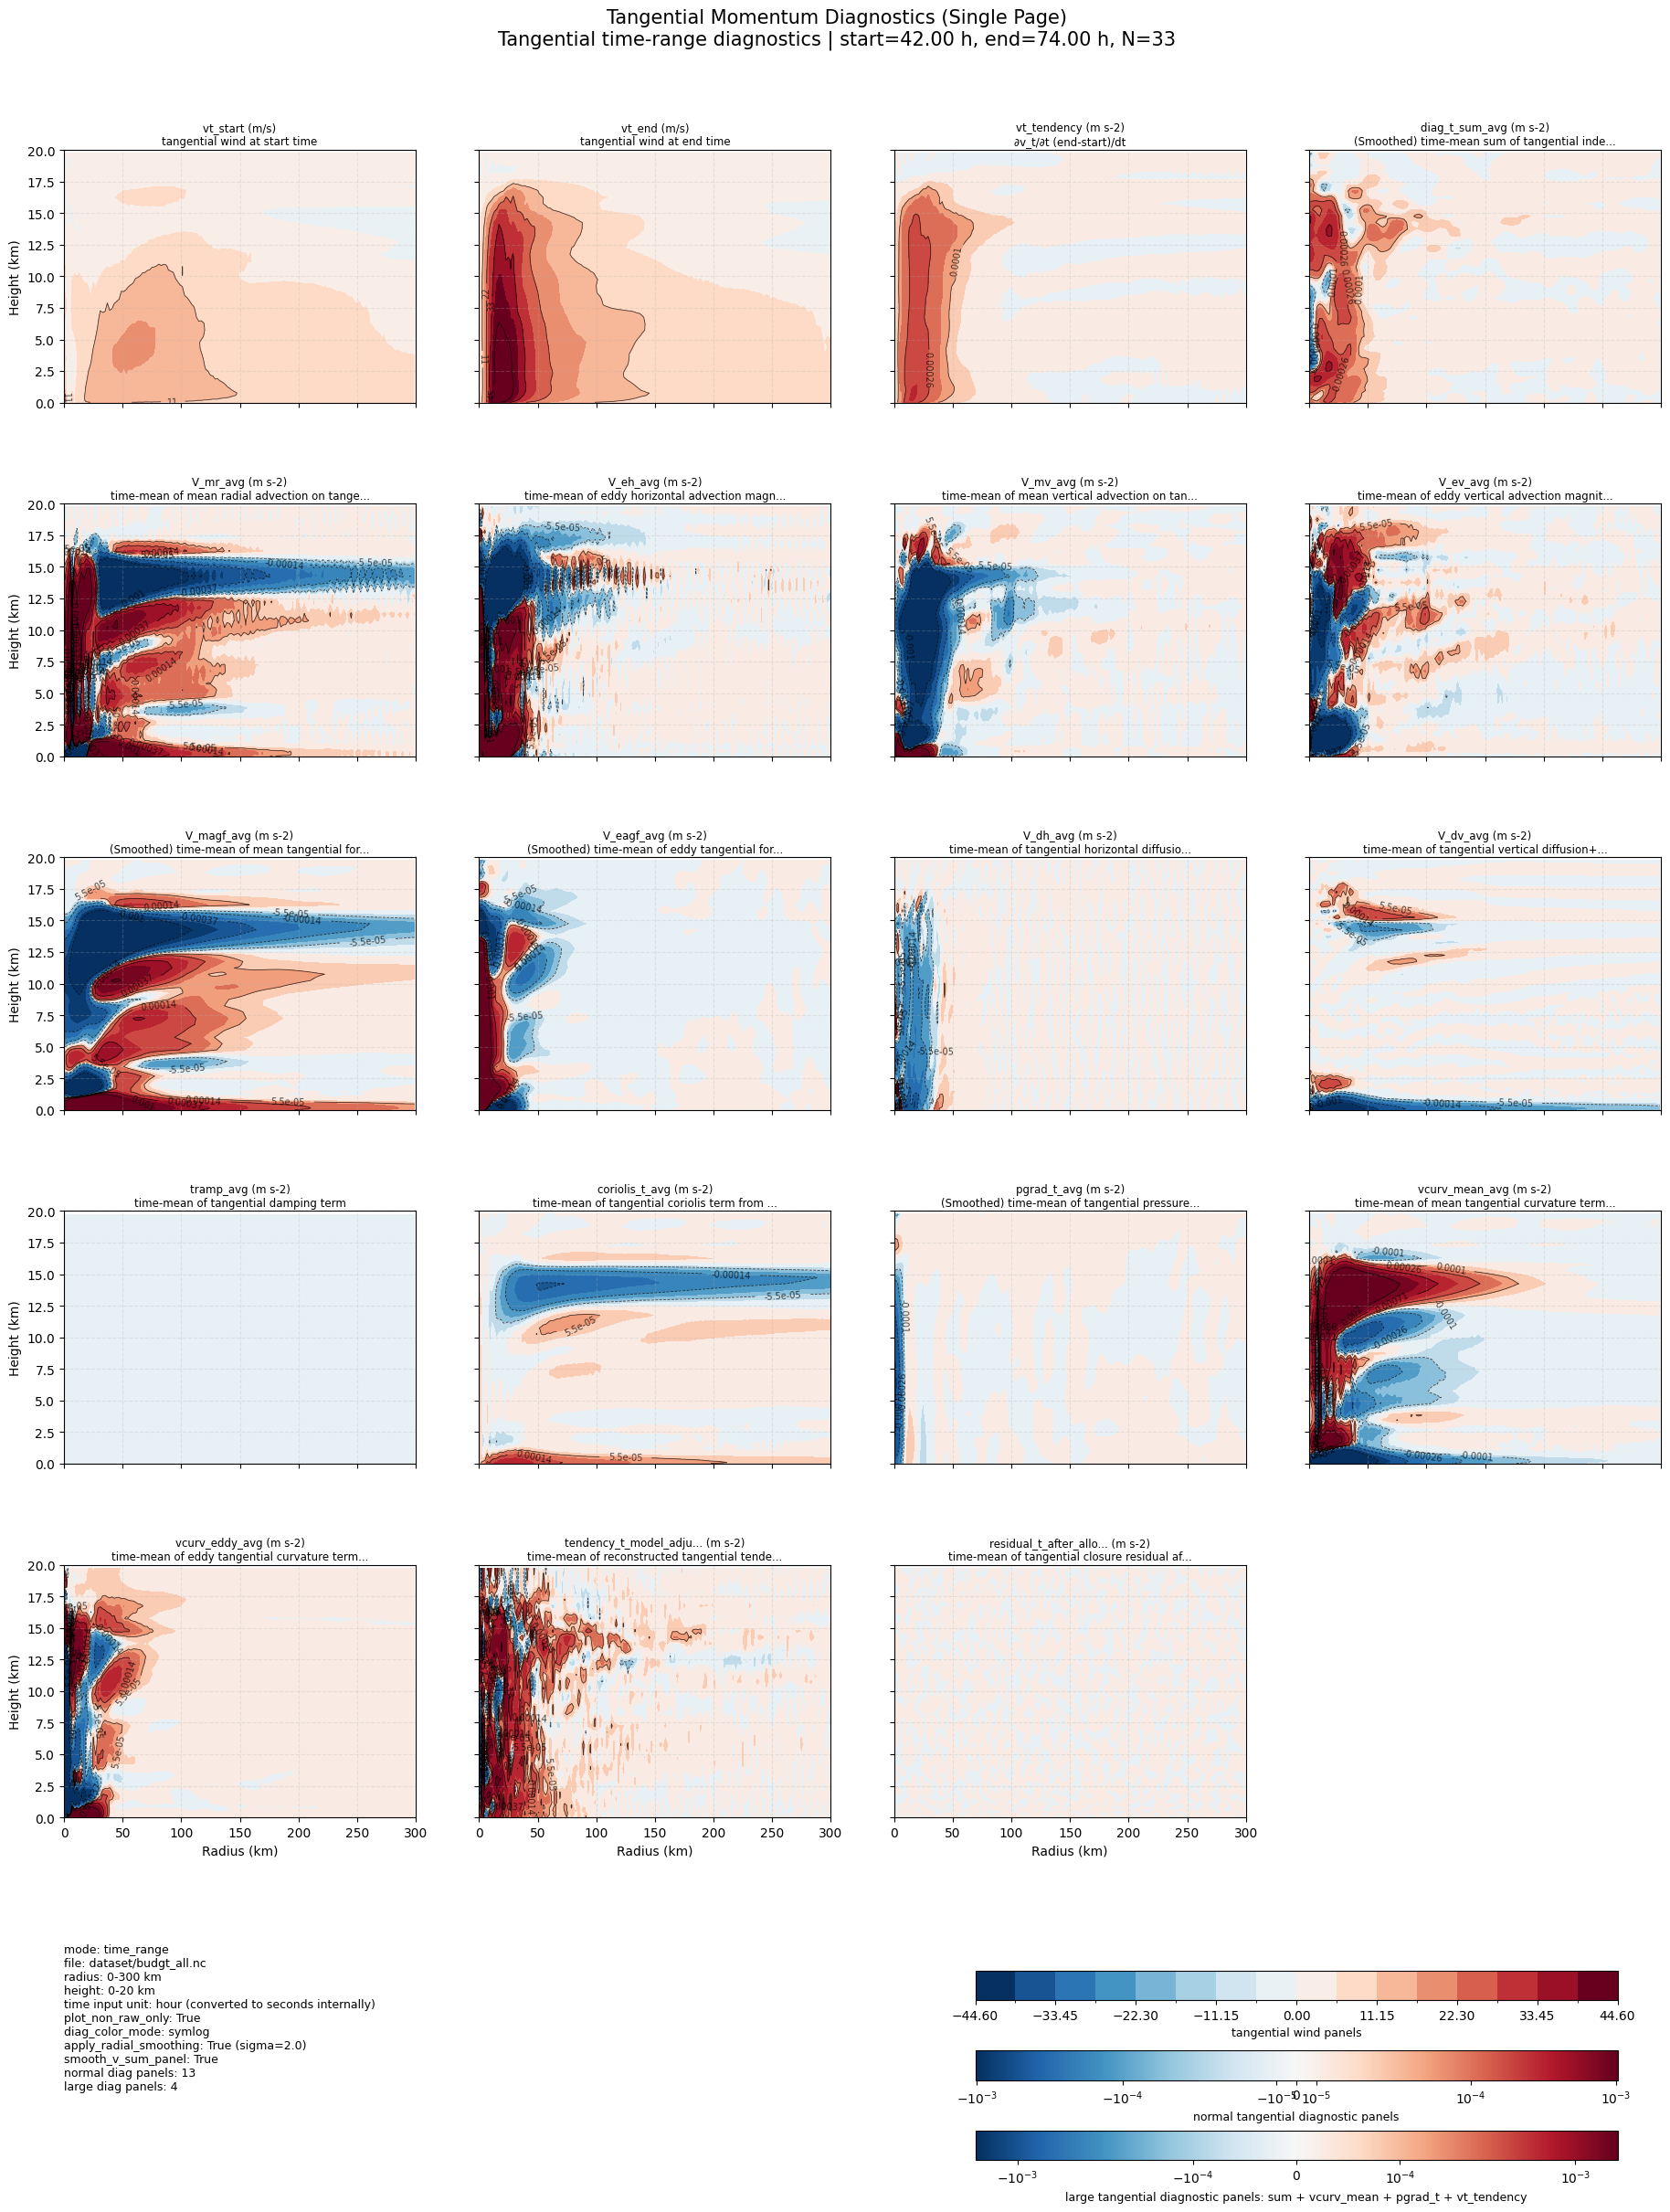

切向诊断绘图完成。


In [4]:
# ==========================
# 6) 切向动量诊断单页绘图（接口与径向图一致）
# 依赖上一个主单元已定义的参数与辅助函数
# ==========================

if "choose_existing_file" not in globals():
    raise RuntimeError("请先运行上一个主绘图单元，再运行本单元。")

# 兼容旧内核：若未定义该开关，则默认关闭
if "smooth_v_sum_panel" not in globals():
    smooth_v_sum_panel = False

nc_file_t = choose_existing_file(candidate_files)
print(f"读取文件(切向): {nc_file_t}")

with Dataset(nc_file_t, "r") as nc:
    time_s = np.asarray(nc.variables["time"][:], dtype=float)
    time_h = time_s / 3600.0

    r_arr = np.asarray(nc.variables["r"][:], dtype=float)
    if "z" in nc.variables:
        z_arr = np.asarray(nc.variables["z"][:], dtype=float)
    elif "zh" in nc.variables:
        z_arr = np.asarray(nc.variables["zh"][:], dtype=float)
    else:
        raise KeyError("未找到 z 或 zh 坐标变量。")

    r_mask = r_arr <= max_r_km
    z_mask = z_arr <= max_z_km
    r_plot = r_arr[r_mask]
    z_plot = z_arr[z_mask]

    var_names = list(nc.variables.keys())

    preferred_diag_t_all = [
        "V_mr", "V_eh", "V_mv", "V_ev",
        "V_magf", "V_eagf", "V_dh", "V_dv", "tramp",
        "V_mr_raw", "V_eh_raw", "V_mv_raw", "V_ev_raw",
        "V_magf_raw", "V_eagf_raw", "V_dh_raw", "V_dv_raw", "tramp_raw",
        "coriolis_t", "pgrad_t", "vcurv_mean", "vcurv_eddy",
        "bt_total_raw", "tendency_t_model_raw", "tendency_t_model_adjusted",
        "residual_t_raw", "residual_t_after_allocation",
    ]

    if plot_non_raw_only:
        preferred_diag_t = [v for v in preferred_diag_t_all if not v.endswith("_raw")]
    else:
        preferred_diag_t = list(preferred_diag_t_all)

    diag_vars_t = [v for v in preferred_diag_t if v in var_names]
    if len(diag_vars_t) == 0:
        raise KeyError("结果文件中未找到可绘制的切向诊断项变量。")

    field_data_t = {}
    field_data_t_unsmoothed = {}
    field_units_t = {}
    field_long_name_t = {}

    smooth_targets_t = []
    for target in smooth_targets:
        if target in ("pgrad_mean", "pgrad_eddy"):
            smooth_targets_t.append("pgrad_t")
        elif target == "U_magf":
            smooth_targets_t.append("V_magf")
        elif target == "U_eagf":
            smooth_targets_t.append("V_eagf")
        else:
            smooth_targets_t.append(target)

    # 快检用：始终保留未平滑的切向 sum
    diag_t_sum_unsmoothed_for_check = None
    diag_t_sum_avg_unsmoothed_for_check = None

    if plot_mode == "time_point":
        target_s = target_hour * 3600.0
        t_idx = nearest_time_index(time_s, target_s)

        field_data_t["vt"] = get_var_2d(nc, "ut", t_idx, z_mask, r_mask)
        field_units_t["vt"] = getattr(nc.variables["ut"], "units", "")
        field_long_name_t["vt"] = getattr(nc.variables["ut"], "long_name", "ut")

        for v in diag_vars_t:
            data_raw = get_var_2d(nc, v, t_idx, z_mask, r_mask)
            field_data_t_unsmoothed[v] = data_raw
            if apply_radial_smoothing and is_smooth_target(v, smooth_targets_t):
                field_data_t[v] = smooth_2d_field(data_raw, smooth_sigma)
                lname_prefix = "(Smoothed) "
            else:
                field_data_t[v] = data_raw
                lname_prefix = ""

            field_units_t[v] = getattr(nc.variables[v], "units", "")
            field_long_name_t[v] = lname_prefix + getattr(nc.variables[v], "long_name", v)

        sum_weights_t = {
            "V_mr": -1, "V_eh": -1, "V_mv": -1, "V_ev": -1,
            "V_magf": 1, "V_eagf": 1, "V_dh": 1, "V_dv": 1, "tramp": 1
        }
        if not plot_non_raw_only:
            sum_weights_t = {k + "_raw": v for k, v in sum_weights_t.items()}

        print("切向 sum 构成符号:", sum_weights_t)

        valid_keys_t = [k for k in sum_weights_t if k in field_data_t_unsmoothed]
        if valid_keys_t:
            field_data_t["diag_t_sum"] = np.sum(
                np.stack([field_data_t_unsmoothed[k] * sum_weights_t[k] for k in valid_keys_t], axis=0),
                axis=0,
            )
            diag_t_sum_unsmoothed_for_check = field_data_t["diag_t_sum"].copy()
            if smooth_v_sum_panel and apply_radial_smoothing:
                field_data_t["diag_t_sum"] = smooth_2d_field(field_data_t["diag_t_sum"], smooth_sigma)
                field_long_name_t["diag_t_sum"] = "(Smoothed) sum of tangential independent forcing terms (unsmoothed source)"
            else:
                field_long_name_t["diag_t_sum"] = "sum of tangential independent forcing terms (unsmoothed)"
            field_units_t["diag_t_sum"] = field_units_t.get(valid_keys_t[0], "")
        else:
            field_data_t["diag_t_sum"] = np.zeros_like(field_data_t["vt"])
            field_units_t["diag_t_sum"] = ""
            field_long_name_t["diag_t_sum"] = "sum of tangential independent forcing terms (unsmoothed)"

        panel_order_t = ["vt", "diag_t_sum"] + diag_vars_t

        title_mode_t = (
            f"Tangential diagnostics | target={target_hour:.2f} h, "
            f"actual={time_h[t_idx]:.2f} h (idx={t_idx})"
        )

    elif plot_mode == "time_range":
        if end_hour < start_hour:
            raise ValueError("end_hour 必须 >= start_hour")

        start_s = start_hour * 3600.0
        end_s = end_hour * 3600.0

        t0 = nearest_time_index(time_s, start_s)
        t1 = nearest_time_index(time_s, end_s)
        if t1 < t0:
            t0, t1 = t1, t0

        time_mask = np.zeros_like(time_s, dtype=bool)
        time_mask[t0:t1 + 1] = True

        field_data_t["vt_start"] = get_var_2d(nc, "ut", t0, z_mask, r_mask)
        field_data_t["vt_end"] = get_var_2d(nc, "ut", t1, z_mask, r_mask)
        field_units_t["vt_start"] = getattr(nc.variables["ut"], "units", "")
        field_units_t["vt_end"] = getattr(nc.variables["ut"], "units", "")
        field_long_name_t["vt_start"] = "tangential wind at start time"
        field_long_name_t["vt_end"] = "tangential wind at end time"

        delta_t_s = end_s - start_s
        if delta_t_s > 0:
            field_data_t["vt_tendency"] = (field_data_t["vt_end"] - field_data_t["vt_start"]) / delta_t_s
        else:
            field_data_t["vt_tendency"] = np.zeros_like(field_data_t["vt_start"])
        field_units_t["vt_tendency"] = "m s-2"
        field_long_name_t["vt_tendency"] = "∂v_t/∂t (end-start)/dt"

        diag_t_avg_names = []
        for v in diag_vars_t:
            v_avg_name = f"{v}_avg"
            diag_t_avg_names.append(v_avg_name)
            data_raw = get_var_2d_mean(nc, v, time_mask, z_mask, r_mask)
            field_data_t_unsmoothed[v_avg_name] = data_raw

            if apply_radial_smoothing and is_smooth_target(v_avg_name, smooth_targets_t):
                field_data_t[v_avg_name] = smooth_2d_field(data_raw, smooth_sigma)
                lname_prefix = "(Smoothed) "
            else:
                field_data_t[v_avg_name] = data_raw
                lname_prefix = ""

            field_units_t[v_avg_name] = getattr(nc.variables[v], "units", "")
            field_long_name_t[v_avg_name] = lname_prefix + f"time-mean of {getattr(nc.variables[v], 'long_name', v)}"

        sum_weights_t = {
            "V_mr": -1, "V_eh": -1, "V_mv": -1, "V_ev": -1,
            "V_magf": 1, "V_eagf": 1, "V_dh": 1, "V_dv": 1, "tramp": 1
        }
        if not plot_non_raw_only:
            sum_weights_t = {k + "_raw": v for k, v in sum_weights_t.items()}

        print("切向 sum 构成符号:", sum_weights_t)

        valid_keys_t_avg = [f"{k}_avg" for k in sum_weights_t if f"{k}_avg" in field_data_t_unsmoothed]
        if valid_keys_t_avg:
            field_data_t["diag_t_sum_avg"] = np.sum(
                np.stack(
                    [field_data_t_unsmoothed[k] * sum_weights_t[k.replace("_avg", "")] for k in valid_keys_t_avg],
                    axis=0,
                ),
                axis=0,
            )
            diag_t_sum_avg_unsmoothed_for_check = field_data_t["diag_t_sum_avg"].copy()
            if smooth_v_sum_panel and apply_radial_smoothing:
                field_data_t["diag_t_sum_avg"] = smooth_2d_field(field_data_t["diag_t_sum_avg"], smooth_sigma)
                field_long_name_t["diag_t_sum_avg"] = "(Smoothed) time-mean sum of tangential independent forcing terms (unsmoothed source)"
            else:
                field_long_name_t["diag_t_sum_avg"] = "time-mean sum of tangential independent forcing terms (unsmoothed)"
            field_units_t["diag_t_sum_avg"] = field_units_t.get(valid_keys_t_avg[0], "")
        else:
            field_data_t["diag_t_sum_avg"] = np.zeros_like(field_data_t["vt_start"])
            field_units_t["diag_t_sum_avg"] = ""
            field_long_name_t["diag_t_sum_avg"] = "time-mean sum of tangential independent forcing terms (unsmoothed)"

        panel_order_t = ["vt_start", "vt_end", "vt_tendency", "diag_t_sum_avg"] + diag_t_avg_names

        title_mode_t = (
            f"Tangential time-range diagnostics | start={time_h[t0]:.2f} h, end={time_h[t1]:.2f} h, "
            f"N={np.sum(time_mask)}"
        )

    else:
        raise ValueError("plot_mode 只能是 'time_point' 或 'time_range'")

# 统一色阶（分组）
vt_keys = [k for k in panel_order_t if k.startswith("vt") and k != "vt_tendency"]
large_key_set_t = {
    "diag_t_sum", "diag_t_sum_avg",
    "vcurv_mean", "vcurv_mean_avg",
    "pgrad_t", "pgrad_t_avg",
    "vt_tendency",
}
large_diag_keys_t = [k for k in panel_order_t if k in large_key_set_t]
small_diag_keys_t = [k for k in panel_order_t if (k not in vt_keys and k not in large_diag_keys_t)]

vt_levels, vt_abs = symmetric_levels_from_data(
    arrays=[field_data_t[k] for k in vt_keys],
    n_levels=n_levels_ur,
    floor=1e-8,
    clip_percentile=99.0,
)
small_levels_t, small_abs_t = symmetric_levels_from_data(
    arrays=[field_data_t[k] for k in small_diag_keys_t],
    n_levels=n_levels_diag,
    floor=1e-12,
    clip_percentile=small_clip_percentile,
)
large_levels_t, large_abs_t = symmetric_levels_from_data(
    arrays=[field_data_t[k] for k in large_diag_keys_t],
    n_levels=n_levels_diag,
    floor=1e-12,
    clip_percentile=large_clip_percentile,
)

vt_norm = BoundaryNorm(vt_levels, ncolors=256, clip=True)
if diag_color_mode == "symlog":
    small_linthresh_t = max(small_abs_t * small_linthresh_ratio, 1e-12)
    large_linthresh_t = max(large_abs_t * large_linthresh_ratio, 1e-12)
    small_levels_t = make_symlog_levels(small_abs_t, small_linthresh_t, n_levels_diag)
    large_levels_t = make_symlog_levels(large_abs_t, large_linthresh_t, n_levels_diag)
    small_norm_t = SymLogNorm(linthresh=small_linthresh_t, vmin=-small_abs_t, vmax=small_abs_t, base=10)
    large_norm_t = SymLogNorm(linthresh=large_linthresh_t, vmin=-large_abs_t, vmax=large_abs_t, base=10)
else:
    small_norm_t = BoundaryNorm(small_levels_t, ncolors=256, clip=True)
    large_norm_t = BoundaryNorm(large_levels_t, ncolors=256, clip=True)

print(f"vt 色阶范围: [{-vt_abs:.3f}, {vt_abs:.3f}]")
print(f"切向普通诊断项色阶范围: [{-small_abs_t:.6f}, {small_abs_t:.6f}] (p{small_clip_percentile})")
print(f"切向大项色阶范围: [{-large_abs_t:.6f}, {large_abs_t:.6f}] (p{large_clip_percentile})")
print(f"切向sum面板平滑开关 smooth_v_sum_panel = {smooth_v_sum_panel}")

# 与诊断方程做一致性快检（时间段模式用平均场）
if plot_mode == "time_range" and "diag_t_sum_avg" in field_data_t and "tendency_t_model_adjusted" in var_names:
    with Dataset(nc_file_t, "r") as nc_chk:
        tmask = np.zeros(len(nc_chk.variables["time"]), dtype=bool)
        tmask[t0:t1 + 1] = True
        tend_t = np.asarray(nc_chk.variables["tendency_t_model_adjusted"][tmask, :, :], dtype=float)
        tend_t_avg = np.nanmean(tend_t[:, z_mask, :][:, :, r_mask], axis=0)
    # 快检始终使用未平滑 sum，避免显示平滑影响闭合判断
    if diag_t_sum_avg_unsmoothed_for_check is not None:
        diff_t = diag_t_sum_avg_unsmoothed_for_check - tend_t_avg
    else:
        diff_t = field_data_t["diag_t_sum_avg"] - tend_t_avg
    print(f"切向sum与tendency_t_model_adjusted差值 mean|.| = {np.nanmean(np.abs(diff_t)):.3e}")

# 单页绘图
R, Z = np.meshgrid(r_plot, z_plot)
n_panels_t = len(panel_order_t)
nrows_t = int(np.ceil(n_panels_t / ncols))
fig_h_t = 4.2 * nrows_t + 4.0

fig, axes = plt.subplots(nrows_t, ncols, figsize=(19, fig_h_t), sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).ravel()

for i, key in enumerate(panel_order_t):
    ax = axes_flat[i]
    data = field_data_t[key]

    if key in vt_keys:
        levels = vt_levels
        norm = vt_norm
    elif key in large_diag_keys_t:
        levels = large_levels_t
        norm = large_norm_t
    else:
        levels = small_levels_t
        norm = small_norm_t

    ax.contourf(R, Z, data, levels=levels, cmap="RdBu_r", norm=norm, extend="both")

    contour_levels = levels[::2]
    contour_levels = contour_levels[~np.isclose(contour_levels, 0.0, atol=1e-15)]
    if contour_levels.size > 0:
        cs = ax.contour(R, Z, data, levels=contour_levels, colors="k", linewidths=0.6, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.2g")

    unit = field_units_t.get(key, "")
    lname = field_long_name_t.get(key, key)
    short_key = shorten_text(key, 22)
    short_lname = shorten_text(lname, 44)
    title1 = f"{short_key} ({unit})" if unit else short_key
    ax.set_title(f"{title1}\n{short_lname}", fontsize=8.5, pad=4)

    ax.grid(True, linestyle="--", alpha=0.25)
    ax.set_xlim(0, max_r_km)
    ax.set_ylim(0, max_z_km)

for i, ax in enumerate(axes_flat):
    if i >= n_panels_t:
        ax.axis("off")
        continue
    if i % ncols == 0:
        ax.set_ylabel("Height (km)", fontsize=10)
    if i >= (nrows_t - 1) * ncols:
        ax.set_xlabel("Radius (km)", fontsize=10)

fig.suptitle(
    "Tangential Momentum Diagnostics (Single Page)\n" + title_mode_t,
    fontsize=15,
    y=0.992,
)
fig.subplots_adjust(left=0.055, right=0.975, bottom=0.20, top=0.93, wspace=0.18, hspace=0.40)

info_lines_t = [
    f"mode: {plot_mode}",
    f"file: {nc_file_t}",
    f"radius: 0-{max_r_km:.0f} km",
    f"height: 0-{max_z_km:.0f} km",
    "time input unit: hour (converted to seconds internally)",
    f"plot_non_raw_only: {plot_non_raw_only}",
    f"diag_color_mode: {diag_color_mode}",
    f"apply_radial_smoothing: {apply_radial_smoothing} (sigma={smooth_sigma})",
    f"smooth_v_sum_panel: {smooth_v_sum_panel}",
    f"normal diag panels: {len(small_diag_keys_t)}",
    f"large diag panels: {len(large_diag_keys_t)}",
]
fig.text(0.055, 0.145, "\n".join(info_lines_t), ha="left", va="top", fontsize=9)

sm_vt = ScalarMappable(norm=vt_norm, cmap="RdBu_r")
sm_vt.set_array([])
sm_small_t = ScalarMappable(norm=small_norm_t, cmap="RdBu_r")
sm_small_t.set_array([])
sm_large_t = ScalarMappable(norm=large_norm_t, cmap="RdBu_r")
sm_large_t.set_array([])

cax1 = fig.add_axes([0.58, 0.12, 0.37, 0.013])
cax2 = fig.add_axes([0.58, 0.085, 0.37, 0.013])
cax3 = fig.add_axes([0.58, 0.05, 0.37, 0.013])

cb1 = fig.colorbar(sm_vt, cax=cax1, orientation="horizontal", ticks=vt_levels[::2])
cb1.set_label("tangential wind panels", fontsize=9)

cb2 = fig.colorbar(sm_small_t, cax=cax2, orientation="horizontal")
cb2.set_label("normal tangential diagnostic panels", fontsize=9)

cb3 = fig.colorbar(sm_large_t, cax=cax3, orientation="horizontal")
cb3.set_label("large tangential diagnostic panels: sum + vcurv_mean + pgrad_t + vt_tendency", fontsize=9)

plt.show()
print("切向诊断绘图完成。")

读取文件(切向新组图): dataset/typhoon_azimuthal_avg_budget_all.nc
新组图 vt 色阶范围: [-44.600, 44.600]
新组图普通诊断项色阶范围: [-0.001109, 0.001109] (p97.0)
新组图大项色阶范围: [-0.000388, 0.000388] (p98.5)


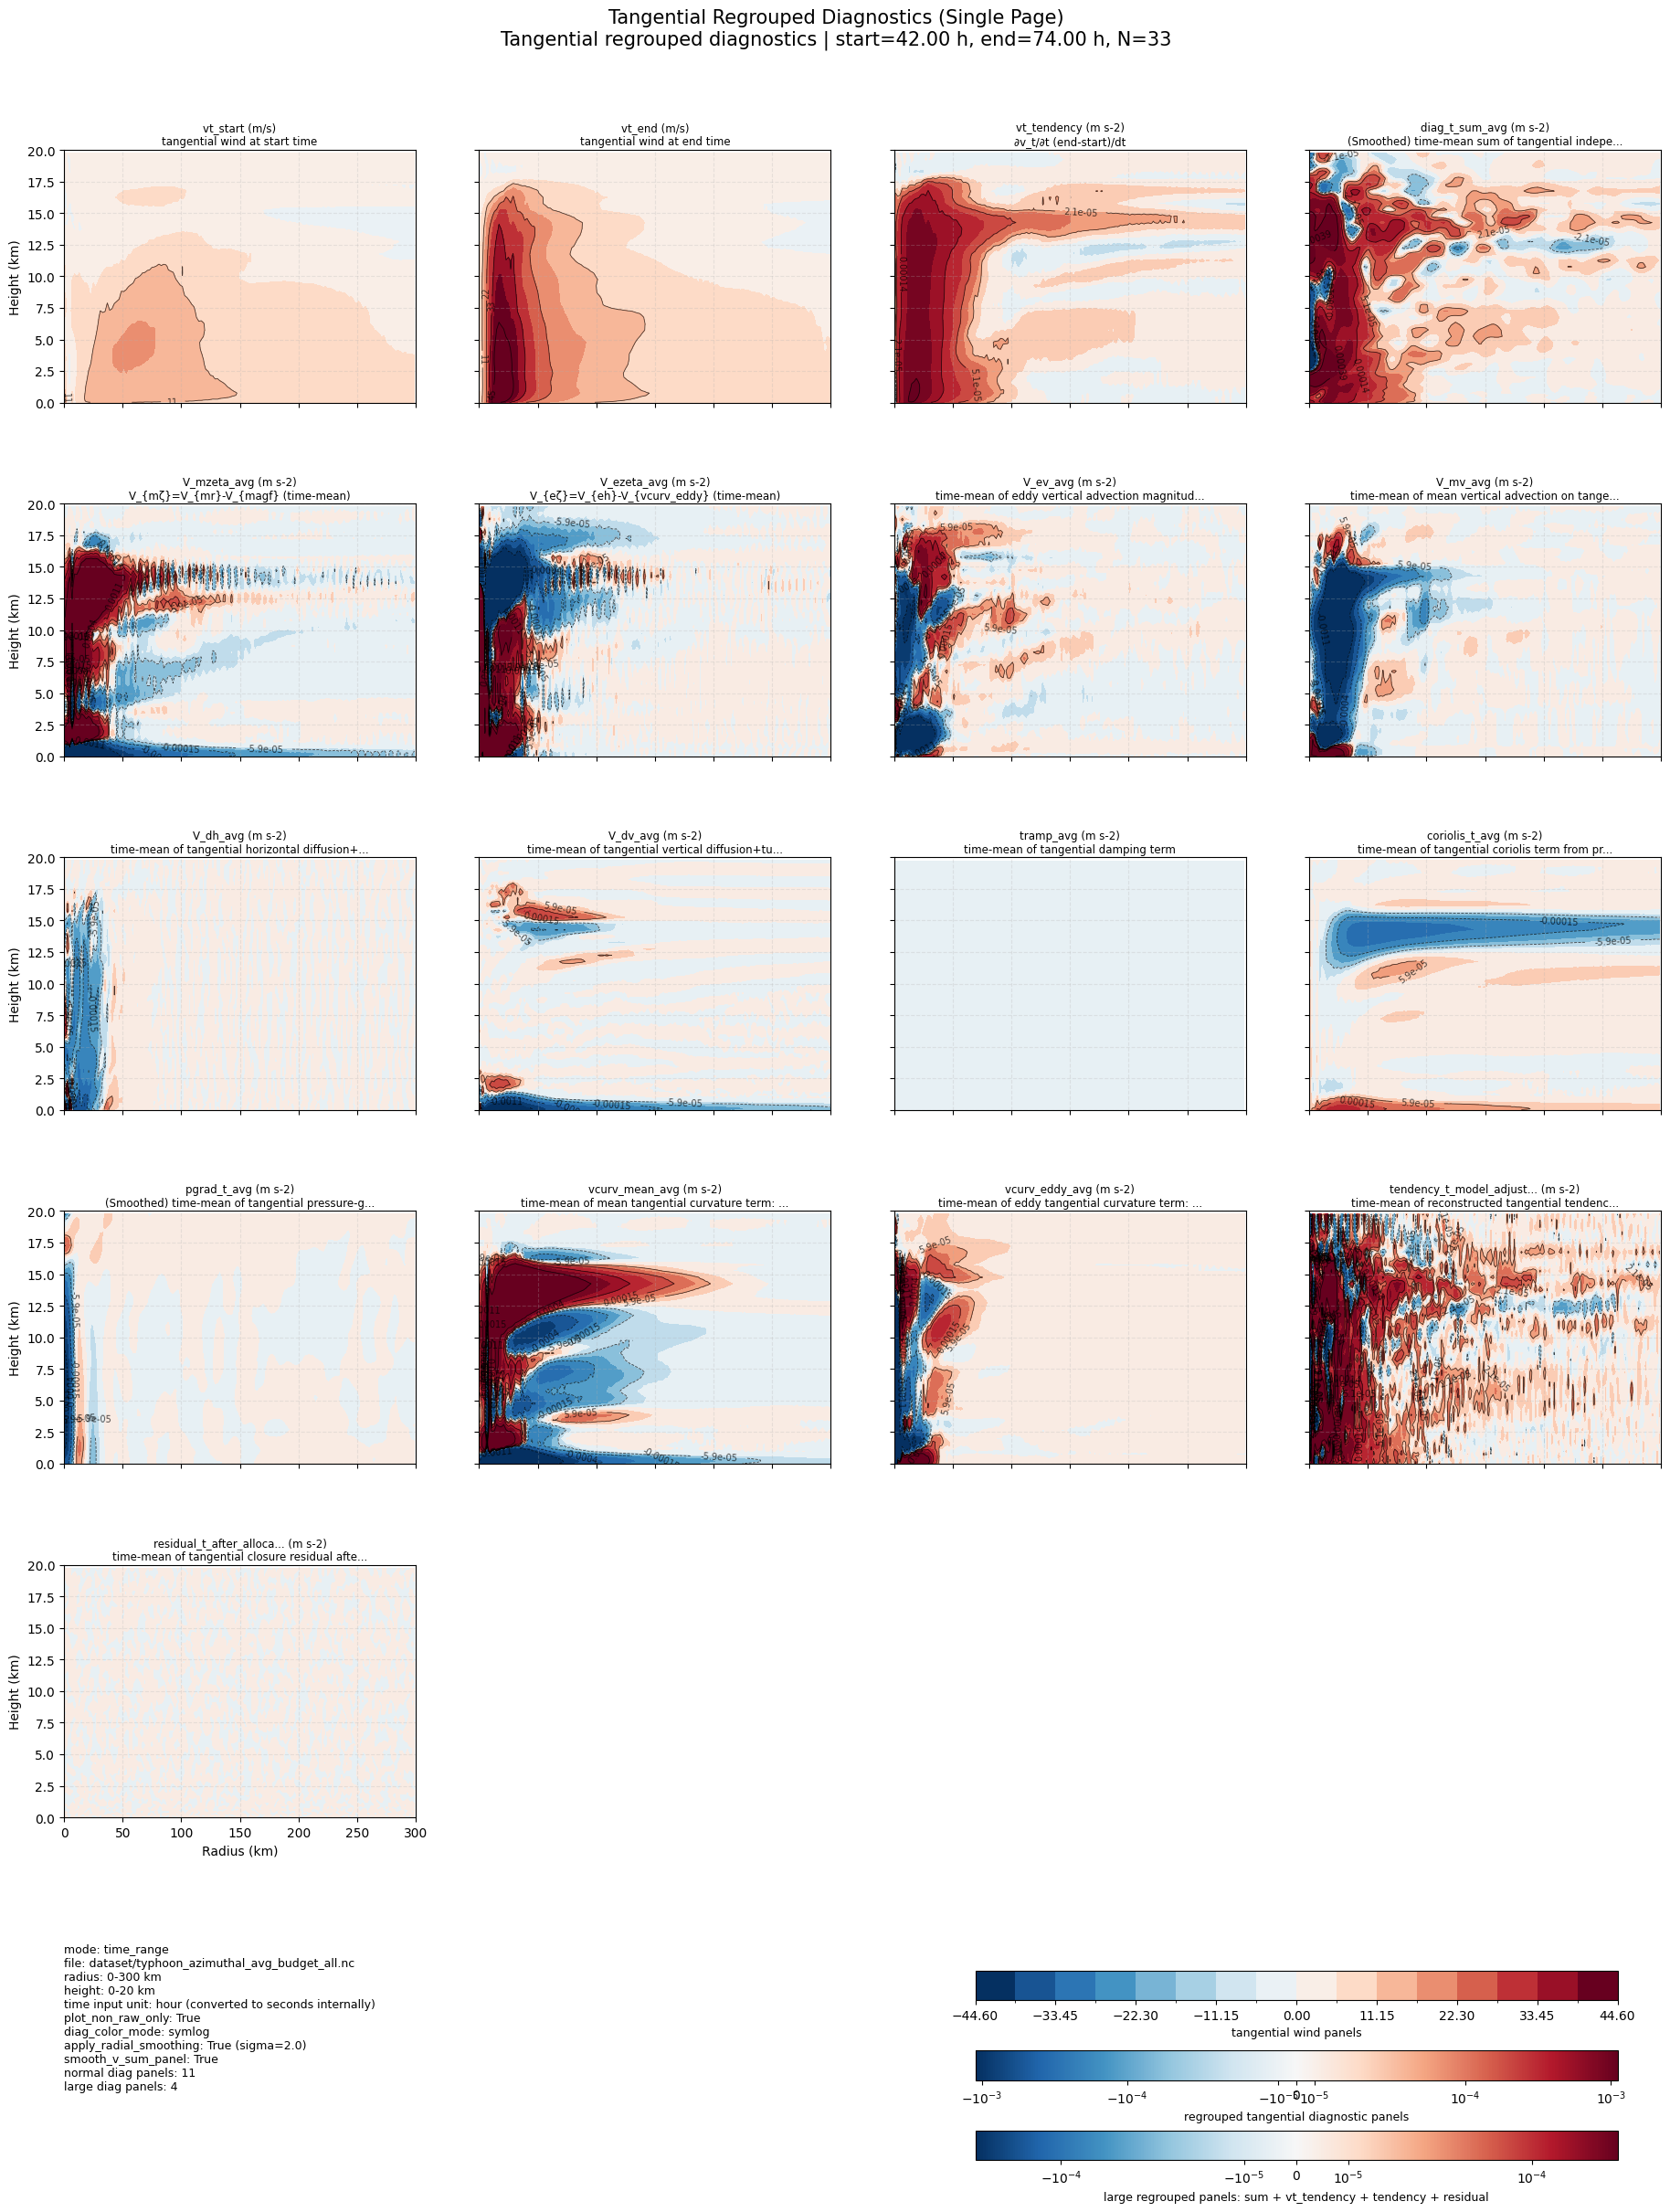

切向新组图绘制完成。


In [7]:
# ==========================
# 6.1) 切向诊断新组图（保留第一行 + 追加 zeta 组合）
# ==========================

if "choose_existing_file" not in globals():
    raise RuntimeError("请先运行第3个单元，再运行本单元。")

if "smooth_v_sum_panel" not in globals():
    smooth_v_sum_panel = False

nc_file_t2 = choose_existing_file(candidate_files)
print(f"读取文件(切向新组图): {nc_file_t2}")

with Dataset(nc_file_t2, "r") as nc:
    time_s = np.asarray(nc.variables["time"][:], dtype=float)
    time_h = time_s / 3600.0

    r_arr = np.asarray(nc.variables["r"][:], dtype=float)
    if "z" in nc.variables:
        z_arr = np.asarray(nc.variables["z"][:], dtype=float)
    elif "zh" in nc.variables:
        z_arr = np.asarray(nc.variables["zh"][:], dtype=float)
    else:
        raise KeyError("未找到 z 或 zh 坐标变量。")

    r_mask = r_arr <= max_r_km
    z_mask = z_arr <= max_z_km
    r_plot = r_arr[r_mask]
    z_plot = z_arr[z_mask]

    # 复用上文平滑接口：U侧目标名映射到V侧
    smooth_targets_t = []
    for target in smooth_targets:
        if target in ("pgrad_mean", "pgrad_eddy"):
            smooth_targets_t.append("pgrad_t")
        elif target == "U_magf":
            smooth_targets_t.append("V_magf")
        elif target == "U_eagf":
            smooth_targets_t.append("V_eagf")
        else:
            smooth_targets_t.append(target)

    field_new = {}
    field_new_unsmoothed = {}
    units_new = {}
    long_new = {}

    def _maybe_smooth(name, arr):
        if apply_radial_smoothing and is_smooth_target(name, smooth_targets_t):
            return smooth_2d_field(arr, smooth_sigma), "(Smoothed) "
        return arr, ""

    if plot_mode == "time_range":
        if end_hour < start_hour:
            raise ValueError("end_hour 必须 >= start_hour")

        start_s = start_hour * 3600.0
        end_s = end_hour * 3600.0
        t0 = nearest_time_index(time_s, start_s)
        t1 = nearest_time_index(time_s, end_s)
        if t1 < t0:
            t0, t1 = t1, t0

        time_mask = np.zeros_like(time_s, dtype=bool)
        time_mask[t0:t1 + 1] = True

        # 第一行保留原四图
        field_new["vt_start"] = get_var_2d(nc, "ut", t0, z_mask, r_mask)
        field_new["vt_end"] = get_var_2d(nc, "ut", t1, z_mask, r_mask)
        units_new["vt_start"] = getattr(nc.variables["ut"], "units", "")
        units_new["vt_end"] = getattr(nc.variables["ut"], "units", "")
        long_new["vt_start"] = "tangential wind at start time"
        long_new["vt_end"] = "tangential wind at end time"

        dt = end_s - start_s
        if dt > 0:
            field_new["vt_tendency"] = (field_new["vt_end"] - field_new["vt_start"]) / dt
        else:
            field_new["vt_tendency"] = np.zeros_like(field_new["vt_start"])
        units_new["vt_tendency"] = "m s-2"
        long_new["vt_tendency"] = "∂v_t/∂t (end-start)/dt"

        need = [
            "V_mr", "V_magf", "V_eh", "vcurv_eddy",
            "V_ev", "V_mv", "V_dh", "V_dv", "tramp",
            "coriolis_t", "pgrad_t", "vcurv_mean",
            "tendency_t_model_adjusted", "residual_t_after_allocation",
            "V_eagf",
        ]
        miss = [v for v in need if v not in nc.variables]
        if miss:
            raise KeyError(f"新组图缺少变量: {miss}")

        for v in need:
            key = f"{v}_avg"
            arr = get_var_2d_mean(nc, v, time_mask, z_mask, r_mask)
            field_new_unsmoothed[key] = arr
            arr_show, prefix = _maybe_smooth(key, arr)
            field_new[key] = arr_show
            units_new[key] = getattr(nc.variables[v], "units", "")
            long_new[key] = prefix + f"time-mean of {getattr(nc.variables[v], 'long_name', v)}"

        # 与上文一致的sum构造接口（默认未平滑源）
        sum_weights_t = {
            "V_mr": -1, "V_eh": -1, "V_mv": -1, "V_ev": -1,
            "V_magf": 1, "V_eagf": 1, "V_dh": 1, "V_dv": 1, "tramp": 1
        }
        valid_keys_t_avg = [f"{k}_avg" for k in sum_weights_t if f"{k}_avg" in field_new_unsmoothed]
        if valid_keys_t_avg:
            diag_sum_avg = np.sum(
                np.stack([field_new_unsmoothed[k] * sum_weights_t[k.replace("_avg", "")] for k in valid_keys_t_avg], axis=0),
                axis=0,
            )
            if smooth_v_sum_panel and apply_radial_smoothing:
                field_new["diag_t_sum_avg"] = smooth_2d_field(diag_sum_avg, smooth_sigma)
                long_new["diag_t_sum_avg"] = "(Smoothed) time-mean sum of tangential independent forcing terms (unsmoothed source)"
            else:
                field_new["diag_t_sum_avg"] = diag_sum_avg
                long_new["diag_t_sum_avg"] = "time-mean sum of tangential independent forcing terms (unsmoothed)"
            units_new["diag_t_sum_avg"] = units_new[valid_keys_t_avg[0]]
        else:
            field_new["diag_t_sum_avg"] = np.zeros_like(field_new["vt_start"])
            units_new["diag_t_sum_avg"] = ""
            long_new["diag_t_sum_avg"] = "time-mean sum of tangential independent forcing terms (unsmoothed)"

        # 你要求的两项组合
        field_new["V_mzeta_avg"] = field_new["V_mr_avg"] - field_new["V_magf_avg"]
        field_new["V_ezeta_avg"] = field_new["V_eh_avg"] - field_new["vcurv_eddy_avg"]
        units_new["V_mzeta_avg"] = units_new["V_mr_avg"]
        units_new["V_ezeta_avg"] = units_new["V_eh_avg"]
        long_new["V_mzeta_avg"] = "V_{mζ}=V_{mr}-V_{magf} (time-mean)"
        long_new["V_ezeta_avg"] = "V_{eζ}=V_{eh}-V_{vcurv_eddy} (time-mean)"

        panel_order_new = [
            "vt_start", "vt_end", "vt_tendency", "diag_t_sum_avg",
            "V_mzeta_avg", "V_ezeta_avg",
            "V_ev_avg", "V_mv_avg", "V_dh_avg", "V_dv_avg", "tramp_avg",
            "coriolis_t_avg", "pgrad_t_avg", "vcurv_mean_avg", "vcurv_eddy_avg",
            "tendency_t_model_adjusted_avg", "residual_t_after_allocation_avg",
        ]

        title_mode_new = (
            f"Tangential regrouped diagnostics | start={time_h[t0]:.2f} h, end={time_h[t1]:.2f} h, N={np.sum(time_mask)}"
        )

    elif plot_mode == "time_point":
        target_s = target_hour * 3600.0
        t_idx = nearest_time_index(time_s, target_s)

        need = [
            "V_mr", "V_magf", "V_eh", "vcurv_eddy",
            "V_ev", "V_mv", "V_dh", "V_dv", "tramp",
            "coriolis_t", "pgrad_t", "vcurv_mean",
            "tendency_t_model_adjusted", "residual_t_after_allocation",
            "V_eagf",
        ]
        miss = [v for v in need if v not in nc.variables]
        if miss:
            raise KeyError(f"新组图缺少变量: {miss}")

        field_new["vt"] = get_var_2d(nc, "ut", t_idx, z_mask, r_mask)
        units_new["vt"] = getattr(nc.variables["ut"], "units", "")
        long_new["vt"] = getattr(nc.variables["ut"], "long_name", "ut")

        for v in need:
            arr = get_var_2d(nc, v, t_idx, z_mask, r_mask)
            field_new_unsmoothed[v] = arr
            arr_show, prefix = _maybe_smooth(v, arr)
            field_new[v] = arr_show
            units_new[v] = getattr(nc.variables[v], "units", "")
            long_new[v] = prefix + getattr(nc.variables[v], "long_name", v)

        sum_weights_t = {
            "V_mr": -1, "V_eh": -1, "V_mv": -1, "V_ev": -1,
            "V_magf": 1, "V_eagf": 1, "V_dh": 1, "V_dv": 1, "tramp": 1
        }
        valid_keys_t = [k for k in sum_weights_t if k in field_new_unsmoothed]
        if valid_keys_t:
            diag_sum = np.sum(np.stack([field_new_unsmoothed[k] * sum_weights_t[k] for k in valid_keys_t], axis=0), axis=0)
            if smooth_v_sum_panel and apply_radial_smoothing:
                field_new["diag_t_sum"] = smooth_2d_field(diag_sum, smooth_sigma)
                long_new["diag_t_sum"] = "(Smoothed) sum of tangential independent forcing terms (unsmoothed source)"
            else:
                field_new["diag_t_sum"] = diag_sum
                long_new["diag_t_sum"] = "sum of tangential independent forcing terms (unsmoothed)"
            units_new["diag_t_sum"] = units_new[valid_keys_t[0]]
        else:
            field_new["diag_t_sum"] = np.zeros_like(field_new["vt"])
            units_new["diag_t_sum"] = ""
            long_new["diag_t_sum"] = "sum of tangential independent forcing terms (unsmoothed)"

        field_new["V_mzeta"] = field_new["V_mr"] - field_new["V_magf"]
        field_new["V_ezeta"] = field_new["V_eh"] - field_new["vcurv_eddy"]
        units_new["V_mzeta"] = units_new["V_mr"]
        units_new["V_ezeta"] = units_new["V_eh"]
        long_new["V_mzeta"] = "V_{mζ}=V_{mr}-V_{magf}"
        long_new["V_ezeta"] = "V_{eζ}=V_{eh}-V_{vcurv_eddy}"

        panel_order_new = [
            "vt", "diag_t_sum", "V_mzeta", "V_ezeta",
            "V_ev", "V_mv", "V_dh", "V_dv", "tramp",
            "coriolis_t", "pgrad_t", "vcurv_mean", "vcurv_eddy",
            "tendency_t_model_adjusted", "residual_t_after_allocation",
        ]
        title_mode_new = f"Tangential regrouped diagnostics | target={target_hour:.2f} h, actual={time_h[t_idx]:.2f} h (idx={t_idx})"

    else:
        raise ValueError("plot_mode 只能是 'time_point' 或 'time_range'")

# === 统一色阶与绘图（与上文同风格） ===
vt_keys_new = [k for k in panel_order_new if k.startswith("vt") and k != "vt_tendency"]
large_key_set_new = {
    "diag_t_sum", "diag_t_sum_avg",
    "vt_tendency",
    "tendency_t_model_adjusted", "tendency_t_model_adjusted_avg",
    "residual_t_after_allocation", "residual_t_after_allocation_avg",
}
large_diag_keys_new = [k for k in panel_order_new if k in large_key_set_new]
small_diag_keys_new = [k for k in panel_order_new if (k not in vt_keys_new and k not in large_diag_keys_new)]

vt_levels_new, vt_abs_new = symmetric_levels_from_data(
    arrays=[field_new[k] for k in vt_keys_new],
    n_levels=n_levels_ur,
    floor=1e-8,
    clip_percentile=99.0,
)
small_levels_new, small_abs_new = symmetric_levels_from_data(
    arrays=[field_new[k] for k in small_diag_keys_new],
    n_levels=n_levels_diag,
    floor=1e-12,
    clip_percentile=small_clip_percentile,
)
large_levels_new, large_abs_new = symmetric_levels_from_data(
    arrays=[field_new[k] for k in large_diag_keys_new],
    n_levels=n_levels_diag,
    floor=1e-12,
    clip_percentile=large_clip_percentile,
)

vt_norm_new = BoundaryNorm(vt_levels_new, ncolors=256, clip=True)
if diag_color_mode == "symlog":
    small_linthresh_new = max(small_abs_new * small_linthresh_ratio, 1e-12)
    large_linthresh_new = max(large_abs_new * large_linthresh_ratio, 1e-12)
    small_levels_new = make_symlog_levels(small_abs_new, small_linthresh_new, n_levels_diag)
    large_levels_new = make_symlog_levels(large_abs_new, large_linthresh_new, n_levels_diag)
    small_norm_new = SymLogNorm(linthresh=small_linthresh_new, vmin=-small_abs_new, vmax=small_abs_new, base=10)
    large_norm_new = SymLogNorm(linthresh=large_linthresh_new, vmin=-large_abs_new, vmax=large_abs_new, base=10)
else:
    small_norm_new = BoundaryNorm(small_levels_new, ncolors=256, clip=True)
    large_norm_new = BoundaryNorm(large_levels_new, ncolors=256, clip=True)

print(f"新组图 vt 色阶范围: [{-vt_abs_new:.3f}, {vt_abs_new:.3f}]")
print(f"新组图普通诊断项色阶范围: [{-small_abs_new:.6f}, {small_abs_new:.6f}] (p{small_clip_percentile})")
print(f"新组图大项色阶范围: [{-large_abs_new:.6f}, {large_abs_new:.6f}] (p{large_clip_percentile})")

R, Z = np.meshgrid(r_plot, z_plot)
n_panels_new = len(panel_order_new)
nrows_new = int(np.ceil(n_panels_new / ncols))
fig_h_new = 4.2 * nrows_new + 4.0

fig, axes = plt.subplots(nrows_new, ncols, figsize=(19, fig_h_new), sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).ravel()

for i, key in enumerate(panel_order_new):
    ax = axes_flat[i]
    data = field_new[key]

    if key in vt_keys_new:
        levels = vt_levels_new
        norm = vt_norm_new
    elif key in large_diag_keys_new:
        levels = large_levels_new
        norm = large_norm_new
    else:
        levels = small_levels_new
        norm = small_norm_new

    ax.contourf(R, Z, data, levels=levels, cmap="RdBu_r", norm=norm, extend="both")
    contour_levels = levels[::2]
    contour_levels = contour_levels[~np.isclose(contour_levels, 0.0, atol=1e-15)]
    if contour_levels.size > 0:
        cs = ax.contour(R, Z, data, levels=contour_levels, colors="k", linewidths=0.6, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.2g")

    unit = units_new.get(key, "")
    lname = long_new.get(key, key)
    short_key = shorten_text(key, 24)
    short_lname = shorten_text(lname, 46)
    title1 = f"{short_key} ({unit})" if unit else short_key
    ax.set_title(f"{title1}\n{short_lname}", fontsize=8.5, pad=4)
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.set_xlim(0, max_r_km)
    ax.set_ylim(0, max_z_km)

for i, ax in enumerate(axes_flat):
    if i >= n_panels_new:
        ax.axis("off")
        continue
    if i % ncols == 0:
        ax.set_ylabel("Height (km)", fontsize=10)
    if i >= (nrows_new - 1) * ncols:
        ax.set_xlabel("Radius (km)", fontsize=10)

fig.suptitle(
    "Tangential Regrouped Diagnostics (Single Page)\n" + title_mode_new,
    fontsize=15,
    y=0.992,
)
fig.subplots_adjust(left=0.055, right=0.975, bottom=0.20, top=0.93, wspace=0.18, hspace=0.40)

info_lines_new = [
    f"mode: {plot_mode}",
    f"file: {nc_file_t2}",
    f"radius: 0-{max_r_km:.0f} km",
    f"height: 0-{max_z_km:.0f} km",
    "time input unit: hour (converted to seconds internally)",
    f"plot_non_raw_only: {plot_non_raw_only}",
    f"diag_color_mode: {diag_color_mode}",
    f"apply_radial_smoothing: {apply_radial_smoothing} (sigma={smooth_sigma})",
    f"smooth_v_sum_panel: {smooth_v_sum_panel}",
    f"normal diag panels: {len(small_diag_keys_new)}",
    f"large diag panels: {len(large_diag_keys_new)}",
]
fig.text(0.055, 0.145, "\n".join(info_lines_new), ha="left", va="top", fontsize=9)

sm_vt = ScalarMappable(norm=vt_norm_new, cmap="RdBu_r")
sm_vt.set_array([])
sm_small = ScalarMappable(norm=small_norm_new, cmap="RdBu_r")
sm_small.set_array([])
sm_large = ScalarMappable(norm=large_norm_new, cmap="RdBu_r")
sm_large.set_array([])

cax1 = fig.add_axes([0.58, 0.12, 0.37, 0.013])
cax2 = fig.add_axes([0.58, 0.085, 0.37, 0.013])
cax3 = fig.add_axes([0.58, 0.05, 0.37, 0.013])

cb1 = fig.colorbar(sm_vt, cax=cax1, orientation="horizontal", ticks=vt_levels_new[::2])
cb1.set_label("tangential wind panels", fontsize=9)
cb2 = fig.colorbar(sm_small, cax=cax2, orientation="horizontal")
cb2.set_label("regrouped tangential diagnostic panels", fontsize=9)
cb3 = fig.colorbar(sm_large, cax=cax3, orientation="horizontal")
cb3.set_label("large regrouped panels: sum + vt_tendency + tendency + residual", fontsize=9)

plt.show()
print("切向新组图绘制完成。")

读取文件(涡度组合): dataset\wind_Thompson.nc
[VORT_COMBO] expression = -(V_mr - V_magf) - V_mv - V_ev - (V_eh - vcurv_eddy) + coriolis_t
[VORT_COMBO] norm_mode = none, scale = 1.000e+00 (original)
[VORT_COMBO] smoothing = True, sigma = 2.0
[VORT_COMBO] clip_percentile = 98.5


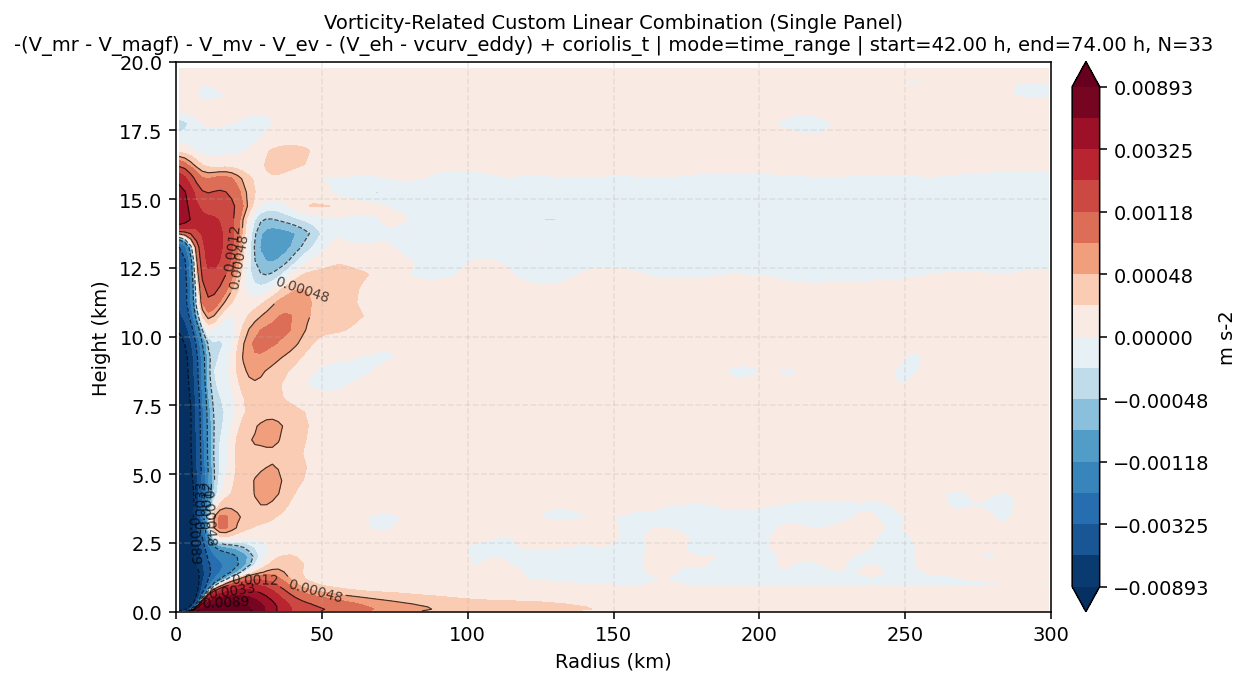

In [9]:
# ==========================
# 6.2) 涡度诊断项后：自定义线性组合单窗图（任意项/任意符号/项数不限）
# 支持直接使用派生项：V_mzeta = V_mr - V_magf, V_ezeta = V_eh - vcurv_eddy
# ==========================

if "choose_existing_file" not in globals():
    raise RuntimeError("请先运行第3个单元，再运行本单元。")

# ---- 用户参数区（可直接改） ----
vort_combo_plot_mode = plot_mode  # "time_point" 或 "time_range"
vort_combo_target_hour = target_hour
vort_combo_start_hour = start_hour
vort_combo_end_hour = end_hour

# 任意线性组合：[(系数, 变量名), ...]
vort_combo_terms = [
    (-1.0, "V_mzeta"),
    (-1.0, "V_mv"),
    (-1.0, "V_ev"),
    (-1.0, "V_ezeta"),
    (1.0, "coriolis_t"),
    
]

# 是否使用 raw 变量（若某 raw 变量不存在会报错）
vort_combo_use_raw = False

# 无损显示平滑：仅对最终组合结果平滑，不改变原始读取值
vort_combo_apply_smoothing = apply_radial_smoothing
vort_combo_smooth_sigma = smooth_sigma

# 标准化模式："none" | "maxabs" | "std"
vort_combo_norm_mode = "none"
vort_combo_norm_eps = 1e-12

# 色阶百分位
vort_combo_clip_percentile = large_clip_percentile

# 派生项定义（可按需扩展）
vort_combo_derived_map = {
    "V_mzeta": ("V_mr", "V_magf"),
    "V_ezeta": ("V_eh", "vcurv_eddy"),
}


def _vort_resolve_raw_name(base_name, use_raw=False):
    if use_raw and not base_name.endswith("_raw"):
        return f"{base_name}_raw"
    return base_name


def _vort_required_vars(term_name, use_raw=False):
    comps = vort_combo_derived_map.get(term_name, None)
    if comps is None:
        return [_vort_resolve_raw_name(term_name, use_raw=use_raw)]
    return [
        _vort_resolve_raw_name(comps[0], use_raw=use_raw),
        _vort_resolve_raw_name(comps[1], use_raw=use_raw),
    ]


def _vort_format_term_label(term_name, use_raw=False):
    comps = vort_combo_derived_map.get(term_name, None)
    if comps is None:
        return _vort_resolve_raw_name(term_name, use_raw=use_raw)
    a = _vort_resolve_raw_name(comps[0], use_raw=use_raw)
    b = _vort_resolve_raw_name(comps[1], use_raw=use_raw)
    return f"({a} - {b})"


def _vort_format_expression(term_list, use_raw=False):
    chunks = []
    for i, (coef, term_name) in enumerate(term_list):
        sign = "+" if coef >= 0 else "-"
        c = abs(float(coef))
        core_name = _vort_format_term_label(term_name, use_raw=use_raw)
        if np.isclose(c, 1.0):
            core = core_name
        else:
            core = f"{c:g}*{core_name}"
        if i == 0:
            chunks.append(core if sign == "+" else f"-{core}")
        else:
            chunks.append(f" {sign} {core}")
    return "".join(chunks)


def _vort_normalize_field(field, mode, eps=1e-12):
    if mode == "none":
        return field, 1.0, "original"
    if mode == "maxabs":
        scale = float(np.nanmax(np.abs(field)))
        scale = max(scale, eps)
        return field / scale, scale, "maxabs"
    if mode == "std":
        scale = float(np.nanstd(field))
        scale = max(scale, eps)
        return field / scale, scale, "std"
    raise ValueError("vort_combo_norm_mode 只能是 'none' / 'maxabs' / 'std'")


if len(vort_combo_terms) == 0:
    raise ValueError("vort_combo_terms 不能为空。")

nc_vort_combo = choose_existing_file(candidate_files)
print(f"读取文件(涡度组合): {nc_vort_combo}")

with Dataset(nc_vort_combo, "r") as nc:
    time_s = np.asarray(nc.variables["time"][:], dtype=float)
    time_h = time_s / 3600.0

    r_arr = np.asarray(nc.variables["r"][:], dtype=float)
    if "z" in nc.variables:
        z_arr = np.asarray(nc.variables["z"][:], dtype=float)
    elif "zh" in nc.variables:
        z_arr = np.asarray(nc.variables["zh"][:], dtype=float)
    else:
        raise KeyError("未找到 z 或 zh 坐标变量。")

    r_mask = r_arr <= max_r_km
    z_mask = z_arr <= max_z_km
    r_plot = r_arr[r_mask]
    z_plot = z_arr[z_mask]

    # 可用性检查
    required_vars = []
    for _, term_name in vort_combo_terms:
        required_vars.extend(_vort_required_vars(term_name, use_raw=vort_combo_use_raw))
    missing_vars = [v for v in sorted(set(required_vars)) if v not in nc.variables]
    if missing_vars:
        raise KeyError(f"涡度组合失败，缺少变量: {missing_vars}")

    if vort_combo_plot_mode == "time_point":
        target_s = vort_combo_target_hour * 3600.0
        t_idx = nearest_time_index(time_s, target_s)

        def _read_var(vname):
            return get_var_2d(nc, vname, t_idx, z_mask, r_mask)

        title_time = f"target={vort_combo_target_hour:.2f} h, actual={time_h[t_idx]:.2f} h (idx={t_idx})"

    elif vort_combo_plot_mode == "time_range":
        if vort_combo_end_hour < vort_combo_start_hour:
            raise ValueError("vort_combo_end_hour 必须 >= vort_combo_start_hour")

        start_s = vort_combo_start_hour * 3600.0
        end_s = vort_combo_end_hour * 3600.0
        t0 = nearest_time_index(time_s, start_s)
        t1 = nearest_time_index(time_s, end_s)
        if t1 < t0:
            t0, t1 = t1, t0

        time_mask = np.zeros_like(time_s, dtype=bool)
        time_mask[t0:t1 + 1] = True

        def _read_var(vname):
            return get_var_2d_mean(nc, vname, time_mask, z_mask, r_mask)

        title_time = f"start={time_h[t0]:.2f} h, end={time_h[t1]:.2f} h, N={np.sum(time_mask)}"

    else:
        raise ValueError("vort_combo_plot_mode 只能是 'time_point' 或 'time_range'")

    combo_field = None
    for coef, term_name in vort_combo_terms:
        comps = vort_combo_derived_map.get(term_name, None)
        if comps is None:
            vn = _vort_resolve_raw_name(term_name, use_raw=vort_combo_use_raw)
            arr = _read_var(vn)
        else:
            v1 = _vort_resolve_raw_name(comps[0], use_raw=vort_combo_use_raw)
            v2 = _vort_resolve_raw_name(comps[1], use_raw=vort_combo_use_raw)
            arr = _read_var(v1) - _read_var(v2)

        if combo_field is None:
            combo_field = np.zeros_like(arr, dtype=float)
        combo_field += float(coef) * arr

# 无损显示平滑
if vort_combo_apply_smoothing:
    combo_show = smooth_2d_field(combo_field, vort_combo_smooth_sigma)
else:
    combo_show = combo_field

# 标准化（作用于显示场）
combo_show, combo_scale, combo_scale_name = _vort_normalize_field(
    combo_show, vort_combo_norm_mode, vort_combo_norm_eps
)

expr_text = _vort_format_expression(vort_combo_terms, use_raw=vort_combo_use_raw)
unit_text = "m s-2" if vort_combo_norm_mode == "none" else "normalized"

R, Z = np.meshgrid(r_plot, z_plot)
levels, vmax = symmetric_levels_from_data(
    arrays=[combo_show],
    n_levels=n_levels_diag,
    floor=1e-12,
    clip_percentile=vort_combo_clip_percentile,
 )

if diag_color_mode == "symlog":
    linthresh = max(vmax * large_linthresh_ratio, 1e-12)
    levels = make_symlog_levels(vmax, linthresh, n_levels_diag)
    norm = SymLogNorm(linthresh=linthresh, vmin=-vmax, vmax=vmax, base=10)
else:
    norm = BoundaryNorm(levels, ncolors=256, clip=True)

fig, ax = plt.subplots(figsize=(8.6, 5.0), dpi=140)
cf = ax.contourf(R, Z, combo_show, levels=levels, cmap="RdBu_r", norm=norm, extend="both")

contour_levels = levels[::2]
contour_levels = contour_levels[~np.isclose(contour_levels, 0.0, atol=1e-15)]
if contour_levels.size > 0:
    cs = ax.contour(R, Z, combo_show, levels=contour_levels, colors="k", linewidths=0.6, alpha=0.7)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.2g")

ax.set_xlim(0, max_r_km)
ax.set_ylim(0, max_z_km)
ax.set_xlabel("Radius (km)")
ax.set_ylabel("Height (km)")
ax.grid(True, linestyle="--", alpha=0.25)
ax.set_title(
    "Vorticity-Related Custom Linear Combination (Single Panel)\n"
    + f"{expr_text} | mode={vort_combo_plot_mode} | {title_time}",
    fontsize=10,
 )

cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label(unit_text)

print(f"[VORT_COMBO] expression = {expr_text}")
print(f"[VORT_COMBO] norm_mode = {vort_combo_norm_mode}, scale = {combo_scale:.3e} ({combo_scale_name})")
print(f"[VORT_COMBO] smoothing = {vort_combo_apply_smoothing}, sigma = {vort_combo_smooth_sigma}")
print(f"[VORT_COMBO] clip_percentile = {vort_combo_clip_percentile}")

plt.tight_layout()
plt.show()

## 切向收支符号与闭合审计（不改图，只做核对）

本单元用于回答两个问题：
1. `diag_t_sum_avg` 的每一项正负号是否与诊断方程一致；
2. 第一行第3/4图不一致是否来自符号问题，还是来自 `vt_tendency` 与时间平均收支的定义差异。

In [4]:
import numpy as np
from netCDF4 import Dataset

if plot_mode != "time_range":
    raise RuntimeError("该审计单元仅用于 time_range 模式，请先将 plot_mode 设为 'time_range' 并运行前面单元。")

nc_audit = choose_existing_file(candidate_files)
print(f"[AUDIT] 当前审计文件: {nc_audit}")
if "_all.nc" in nc_audit:
    print("[AUDIT][WARNING] 当前优先读取的是 *_all.nc。若你刚重算的是 typhoon_azimuthal_avg_budget.nc，请先把 candidate_files 的第一项改成它。")

with Dataset(nc_audit, "r") as nc:
    time_s_all = np.asarray(nc.variables["time"][:], dtype=float)

    # 使用与绘图完全一致的索引
    t0_a = nearest_time_index(time_s_all, start_hour * 3600.0)
    t1_a = nearest_time_index(time_s_all, end_hour * 3600.0)
    if t1_a < t0_a:
        t0_a, t1_a = t1_a, t0_a

    tm = np.zeros_like(time_s_all, dtype=bool)
    tm[t0_a:t1_a + 1] = True

    r_all = np.asarray(nc.variables["r"][:], dtype=float)
    if "z" in nc.variables:
        z_all = np.asarray(nc.variables["z"][:], dtype=float)
    else:
        z_all = np.asarray(nc.variables["zh"][:], dtype=float)

    r_m = r_all <= max_r_km
    z_m = z_all <= max_z_km

    def tmean2(vn):
        arr = np.asarray(nc.variables[vn][tm, :, :], dtype=float)
        return np.nanmean(arr[:, z_m, :][:, :, r_m], axis=0)

    required = [
        "V_mr", "V_eh", "V_mv", "V_ev",
        "V_magf", "V_eagf", "V_dh", "V_dv", "tramp",
        "tendency_t_model_adjusted", "ut",
    ]
    miss = [v for v in required if v not in nc.variables]
    if miss:
        raise KeyError(f"审计失败，缺少变量: {miss}")

    V_mr = tmean2("V_mr")
    V_eh = tmean2("V_eh")
    V_mv = tmean2("V_mv")
    V_ev = tmean2("V_ev")
    V_magf = tmean2("V_magf")
    V_eagf = tmean2("V_eagf")
    V_dh = tmean2("V_dh")
    V_dv = tmean2("V_dv")
    tramp = tmean2("tramp")
    tend_model = tmean2("tendency_t_model_adjusted")

    # 1) 当前代码采用的符号（应与方程一致）
    sum_ok = -V_mr - V_eh - V_mv - V_ev + V_magf + V_eagf + V_dh + V_dv + tramp
    err_ok = np.nanmean(np.abs(sum_ok - tend_model))

    # 2) 反号试验（若这里反而更小，才说明符号可能写反）
    sum_wrong_adv = +V_mr + V_eh + V_mv + V_ev + V_magf + V_eagf + V_dh + V_dv + tramp
    err_wrong_adv = np.nanmean(np.abs(sum_wrong_adv - tend_model))

    # 3) 与端点差分 tendency 的比较：输入 dt vs 实际索引 dt
    ut0 = np.asarray(nc.variables["ut"][t0_a, z_m, :][:, r_m], dtype=float)
    ut1 = np.asarray(nc.variables["ut"][t1_a, z_m, :][:, r_m], dtype=float)

    dt_input = float(end_hour * 3600.0 - start_hour * 3600.0)
    dt_actual = float(time_s_all[t1_a] - time_s_all[t0_a])

    vt_tend_input = (ut1 - ut0) / dt_input if dt_input > 0 else np.zeros_like(ut0)
    vt_tend_actual = (ut1 - ut0) / dt_actual if dt_actual > 0 else np.zeros_like(ut0)

    err_vs_input = np.nanmean(np.abs(sum_ok - vt_tend_input))
    err_vs_actual = np.nanmean(np.abs(sum_ok - vt_tend_actual))

print("\n[AUDIT] 切向符号/闭合核对结果")
print(f"[AUDIT] mean|sum_ok - tendency_t_model_adjusted_avg| = {err_ok:.3e}")
print(f"[AUDIT] mean|sum_wrong_adv - tendency_t_model_adjusted_avg| = {err_wrong_adv:.3e}")
if err_ok <= err_wrong_adv:
    print("[AUDIT] 结论: 当前 advection 负号写法正确；改成正号会更差。")
else:
    print("[AUDIT][ALERT] 反号试验更优，请进一步检查变量符号定义。")

print(f"[AUDIT] mean|sum_ok - vt_tendency(输入dt)| = {err_vs_input:.3e}")
print(f"[AUDIT] mean|sum_ok - vt_tendency(实际索引dt)| = {err_vs_actual:.3e}")
print(f"[AUDIT] dt_input = {dt_input:.1f}s, dt_actual = {dt_actual:.1f}s")
print("[AUDIT] 若 sum_ok 与 tendency_t_model_adjusted 闭合而与 vt_tendency 差异大，主因通常是: 端点差分定义 + 随时间移动中心坐标造成的非惯性差异，而非 sum 项正负号错误。")

[AUDIT] 当前审计文件: dataset/typhoon_azimuthal_avg_budget_all.nc
[AUDIT][WARNING] 当前优先读取的是 *_all.nc。若你刚重算的是 typhoon_azimuthal_avg_budget.nc，请先把 candidate_files 的第一项改成它。

[AUDIT] 切向符号/闭合核对结果
[AUDIT] mean|sum_ok - tendency_t_model_adjusted_avg| = 1.651e-11
[AUDIT] mean|sum_wrong_adv - tendency_t_model_adjusted_avg| = 1.089e-03
[AUDIT] 结论: 当前 advection 负号写法正确；改成正号会更差。
[AUDIT] mean|sum_ok - vt_tendency(输入dt)| = 4.893e-05
[AUDIT] mean|sum_ok - vt_tendency(实际索引dt)| = 4.893e-05
[AUDIT] dt_input = 115200.0s, dt_actual = 115200.0s
[AUDIT] 若 sum_ok 与 tendency_t_model_adjusted 闭合而与 vt_tendency 差异大，主因通常是: 端点差分定义 + 随时间移动中心坐标造成的非惯性差异，而非 sum 项正负号错误。


## 内核区可靠性附加诊断
用于快速判断 0–25 km 内 eddy 异常是物理信号还是诊断噪声，新增三图：
1. `residual_raw` 在 0–25 km 的时间-高度演变；
2. 各半径环样本点数（几何采样充足性）；
3. 内核项径向剖面对比（`U_eh_avg`、`U_ev_avg`、`pgrad_eddy_avg`、`curv_eddy_avg`）。


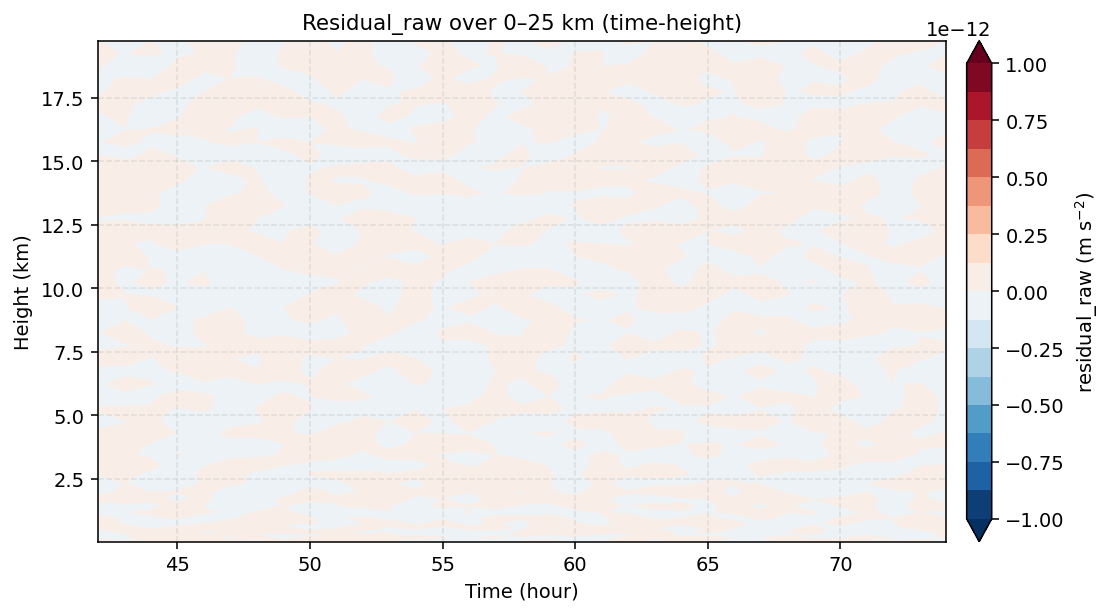

In [5]:
# 图1：residual_raw 时间-高度（0-25 km 平均）
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

diag_r_limit_km = 25.0

with Dataset(nc_file, "r") as nc_chk:
    r_all = np.asarray(nc_chk.variables["r"][:], dtype=float)
    z_all = np.asarray(nc_chk.variables["z"][:] if "z" in nc_chk.variables else nc_chk.variables["zh"][:], dtype=float)
    t_all_h = np.asarray(nc_chk.variables["time"][:], dtype=float) / 3600.0
    r_mask25 = r_all <= diag_r_limit_km
    z_mask_plot = z_all <= max_z_km

    if "residual_raw" not in nc_chk.variables:
        raise KeyError("文件中缺少 residual_raw，无法绘制图1。")

    res_tzr = np.asarray(nc_chk.variables["residual_raw"][:, z_mask_plot, :][:, :, r_mask25], dtype=float)
    res_tz = np.nanmean(res_tzr, axis=2)  # (time, z)

# 仅显示当前时间段（若主单元已定义）
if plot_mode == "time_range":
    t_mask_use = np.zeros_like(t_all_h, dtype=bool)
    t_mask_use[t0:t1+1] = True
else:
    t_mask_use = np.ones_like(t_all_h, dtype=bool)

res_show = res_tz[t_mask_use, :]
t_show = t_all_h[t_mask_use]

vabs = np.nanpercentile(np.abs(res_show), 98.0)
vabs = max(float(vabs), 1e-12)
levels = np.linspace(-vabs, vabs, 17)

TT, ZZ = np.meshgrid(t_show, z_all[z_mask_plot], indexing="ij")
fig, ax = plt.subplots(figsize=(8.2, 4.5), dpi=140)
cf = ax.contourf(TT, ZZ, res_show, levels=levels, cmap="RdBu_r", extend="both")
ax.set_title("Residual_raw over 0–25 km (time-height)", fontsize=11)
ax.set_xlabel("Time (hour)")
ax.set_ylabel("Height (km)")
ax.grid(True, ls="--", alpha=0.3)
cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label("residual_raw (m s$^{-2}$)")
plt.tight_layout()
plt.show()

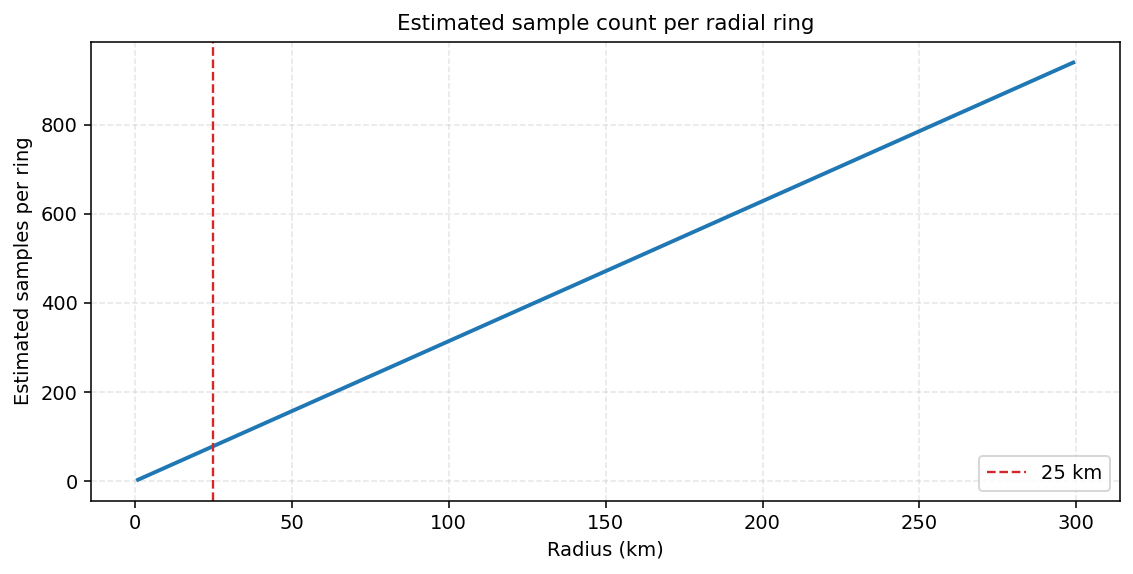

r=2 km 约样本数: 3.1
r=10 km 约样本数: 28.3
r=25 km 约样本数: 78.5


In [6]:
# 图2：各半径环样本点数（几何采样）
import numpy as np
import matplotlib.pyplot as plt

if len(r_plot) < 2:
    raise ValueError("r_plot 长度不足，无法估算环样本数。")

dr_est = float(np.nanmedian(np.diff(r_plot)))
dr_est = max(dr_est, 1e-6)

# 近似：每个环的样本点数 ~ 圆环面积 / 网格面积
ring_area = np.pi * ((r_plot + 0.5 * dr_est)**2 - np.maximum(r_plot - 0.5 * dr_est, 0.0)**2)
grid_area = dr_est * dr_est
n_samples_ring = ring_area / grid_area

fig, ax = plt.subplots(figsize=(8.2, 4.2), dpi=140)
ax.plot(r_plot, n_samples_ring, lw=2.0, color="tab:blue")
ax.axvline(25.0, ls="--", lw=1.2, color="tab:red", label="25 km")
ax.set_title("Estimated sample count per radial ring", fontsize=11)
ax.set_xlabel("Radius (km)")
ax.set_ylabel("Estimated samples per ring")
ax.grid(True, ls="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"r=2 km 约样本数: {n_samples_ring[np.argmin(np.abs(r_plot-2.0))]:.1f}")
print(f"r=10 km 约样本数: {n_samples_ring[np.argmin(np.abs(r_plot-10.0))]:.1f}")
print(f"r=25 km 约样本数: {n_samples_ring[np.argmin(np.abs(r_plot-25.0))]:.1f}")

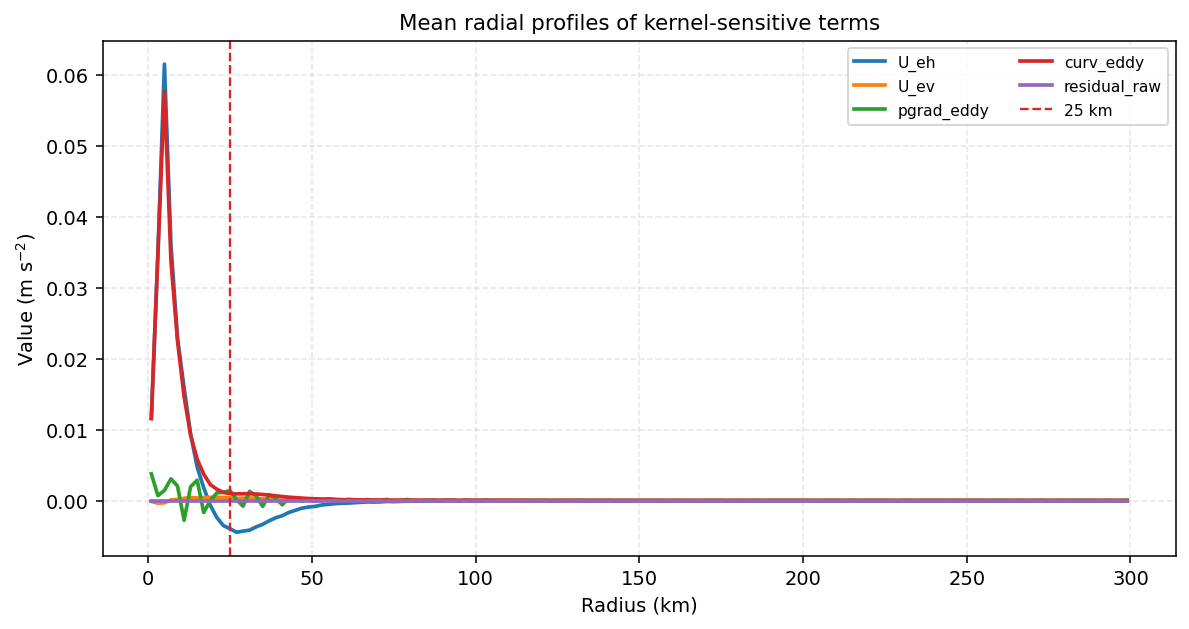

0–25 km 平均绝对值：
  U_eh: 1.608e-02
  U_ev: 3.333e-04
  pgrad_eddy: 1.842e-03
  curv_eddy: 1.534e-02
  residual_raw: 7.059e-20


In [7]:
# 图3：内核项径向剖面对比（时间平均）
import numpy as np
import matplotlib.pyplot as plt

with Dataset(nc_file, "r") as nc_chk:
    r_all = np.asarray(nc_chk.variables["r"][:], dtype=float)
    z_all = np.asarray(nc_chk.variables["z"][:] if "z" in nc_chk.variables else nc_chk.variables["zh"][:], dtype=float)
    r_mask_use = r_all <= max_r_km
    z_mask_use = z_all <= max_z_km

    if plot_mode == "time_range":
        t_mask = np.zeros(len(nc_chk.variables["time"]), dtype=bool)
        t_mask[t0:t1+1] = True
    else:
        t_mask = np.zeros(len(nc_chk.variables["time"]), dtype=bool)
        t_mask[t_idx] = True

    candidates = [
        "U_eh", "U_ev", "pgrad_eddy", "curv_eddy", "residual_raw"
    ]
    exist = [v for v in candidates if v in nc_chk.variables]
    if len(exist) == 0:
        raise KeyError("图3候选变量都不存在。")

    # 先对时间平均，再对高度平均，得到径向剖面
    profiles = {}
    for v in exist:
        arr_tzr = np.asarray(nc_chk.variables[v][t_mask, :, :][:, z_mask_use, :][:, :, r_mask_use], dtype=float)
        prof_r = np.nanmean(np.nanmean(arr_tzr, axis=0), axis=0)
        profiles[v] = prof_r

r_use = r_all[r_mask_use]
r25 = r_use <= 25.0

fig, ax = plt.subplots(figsize=(8.6, 4.6), dpi=140)
for v, p in profiles.items():
    ax.plot(r_use, p, lw=1.9, label=v)

ax.axvline(25.0, ls="--", lw=1.2, color="tab:red", label="25 km")
ax.set_title("Mean radial profiles of kernel-sensitive terms", fontsize=11)
ax.set_xlabel("Radius (km)")
ax.set_ylabel("Value (m s$^{-2}$)")
ax.grid(True, ls="--", alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

print("0–25 km 平均绝对值：")
for v, p in profiles.items():
    m = float(np.nanmean(np.abs(p[r25])))
    print(f"  {v}: {m:.3e}")